In [42]:
import pandas as pd
from plotnine import *

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [40]:
def graph_plots(summary,variable_name,x_axis_name):
    # variable name is true var name, x-axis name is specific name for x-axis label (like if need latex)
    p = (
        ggplot(summary[summary['run_name'].isin(['SCoNE'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

    # baseline methods
    p = (
        ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

    # comparator methods
    p = (
        ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

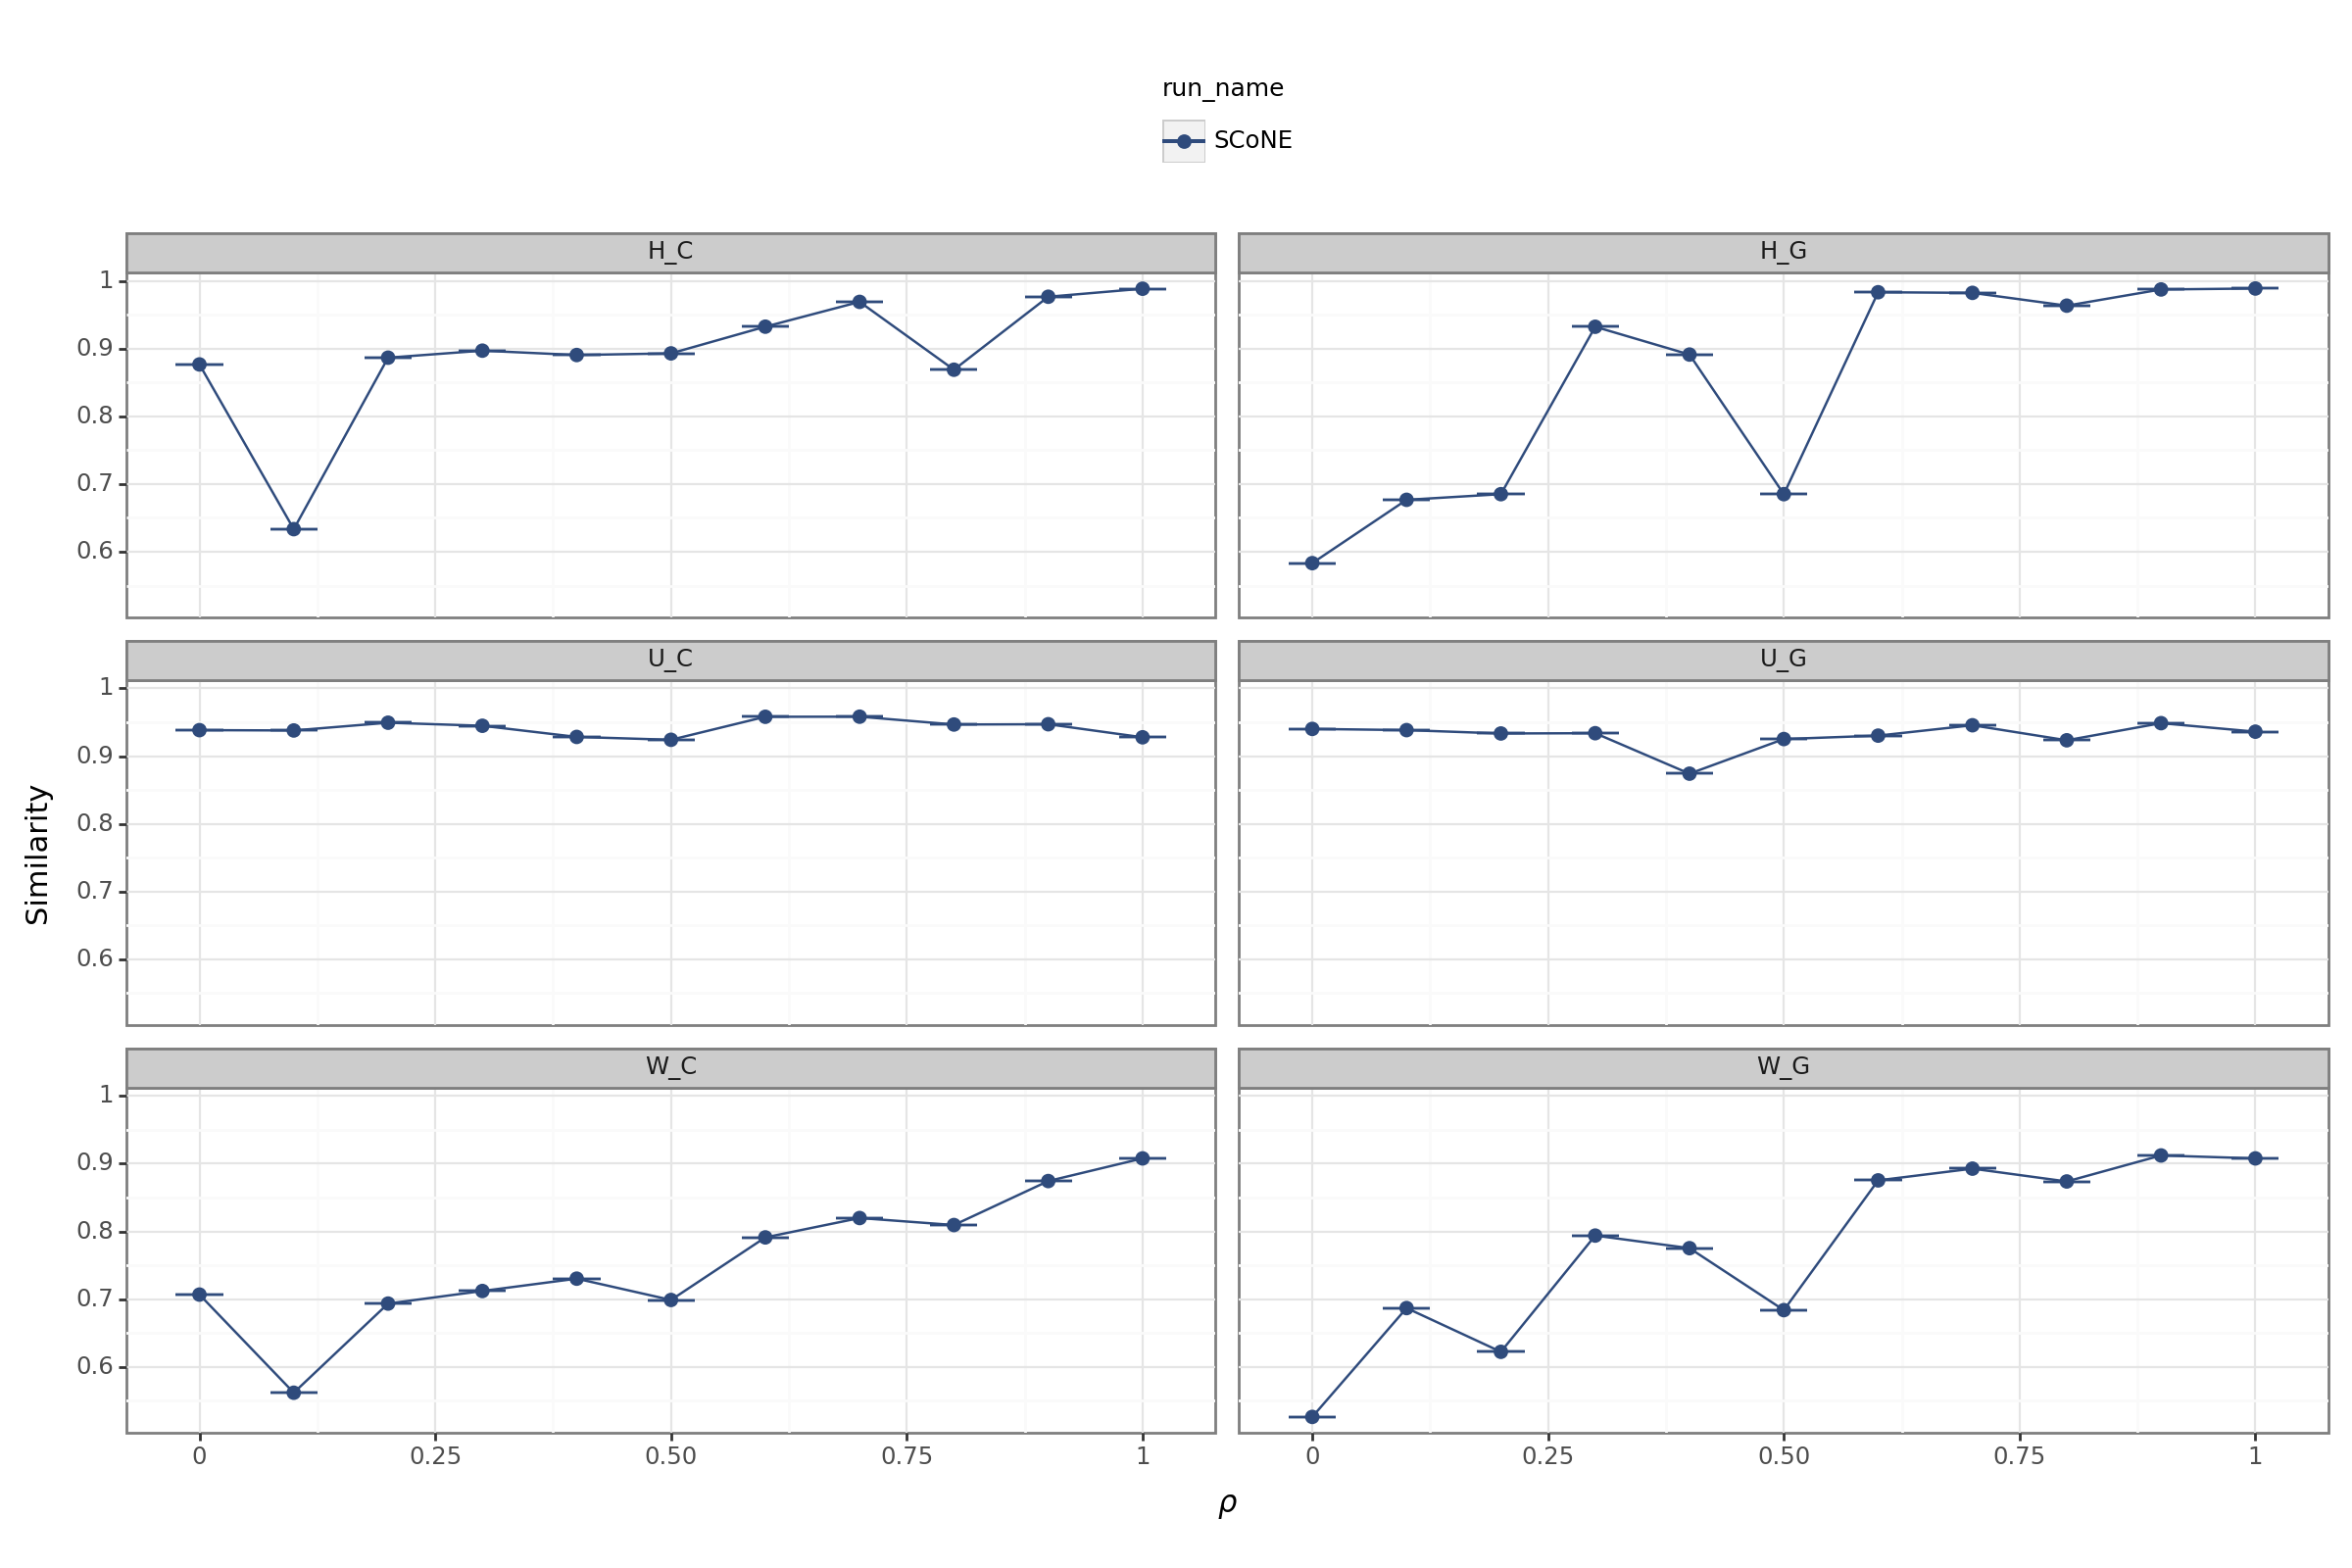

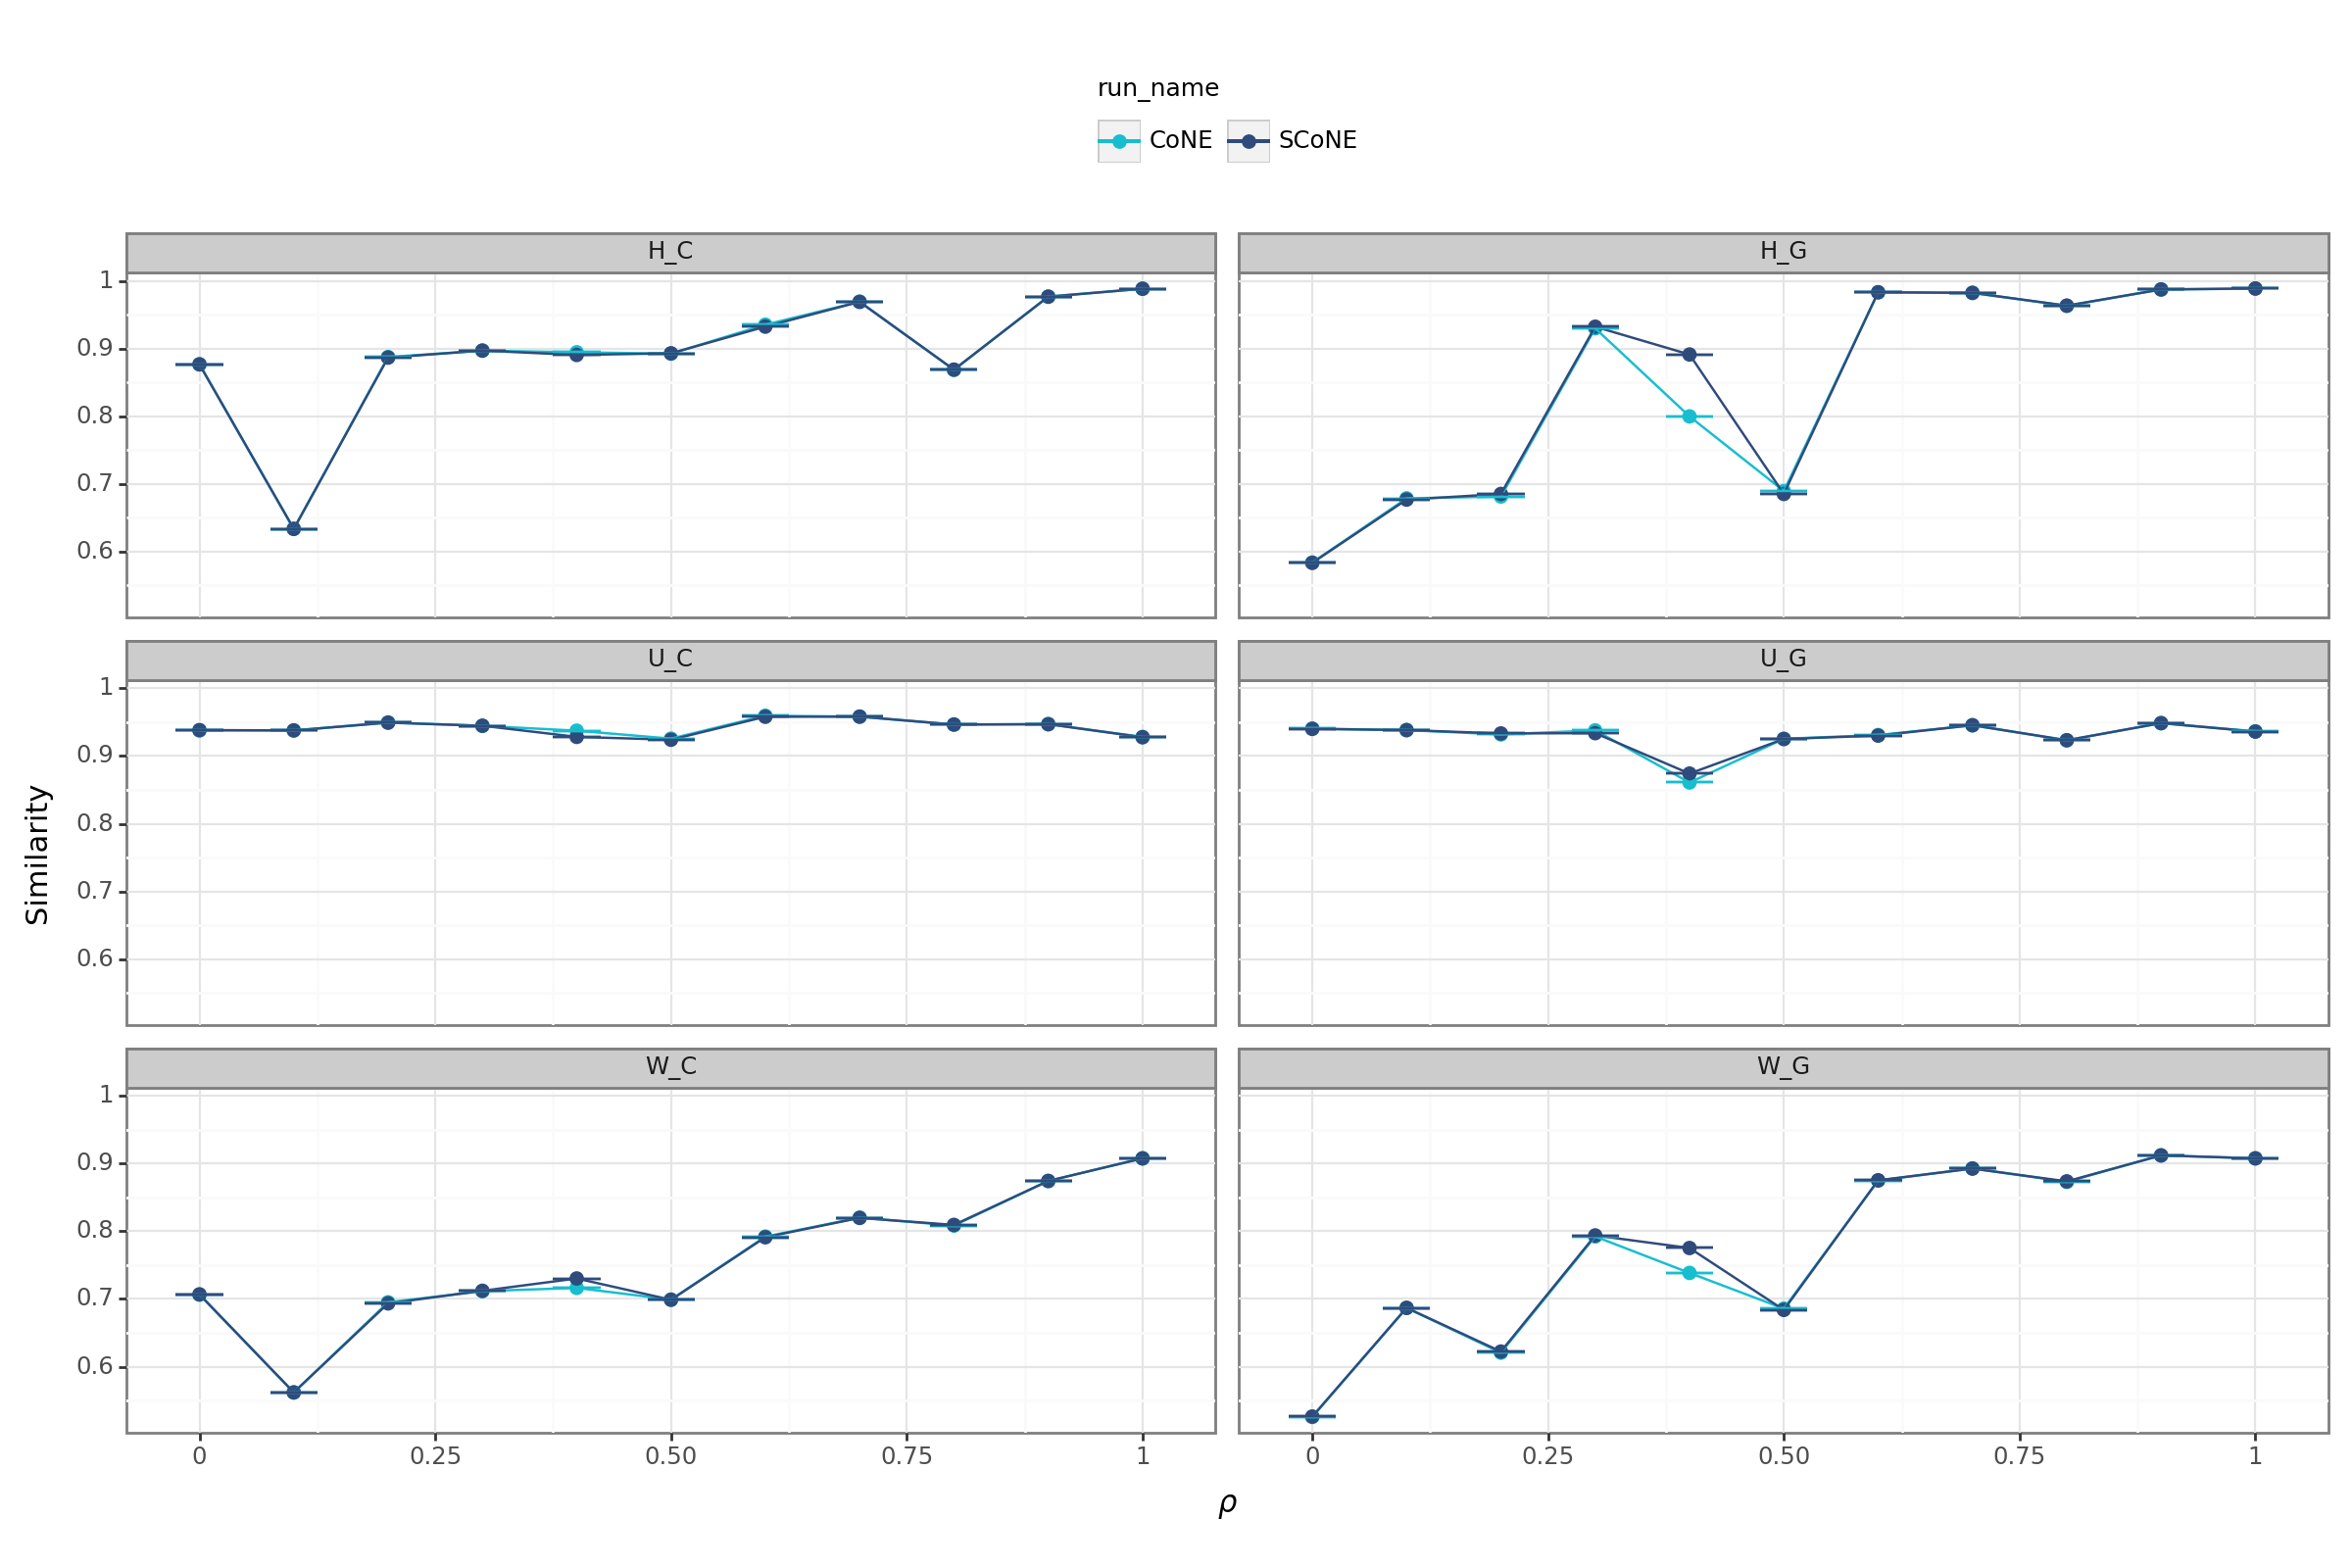

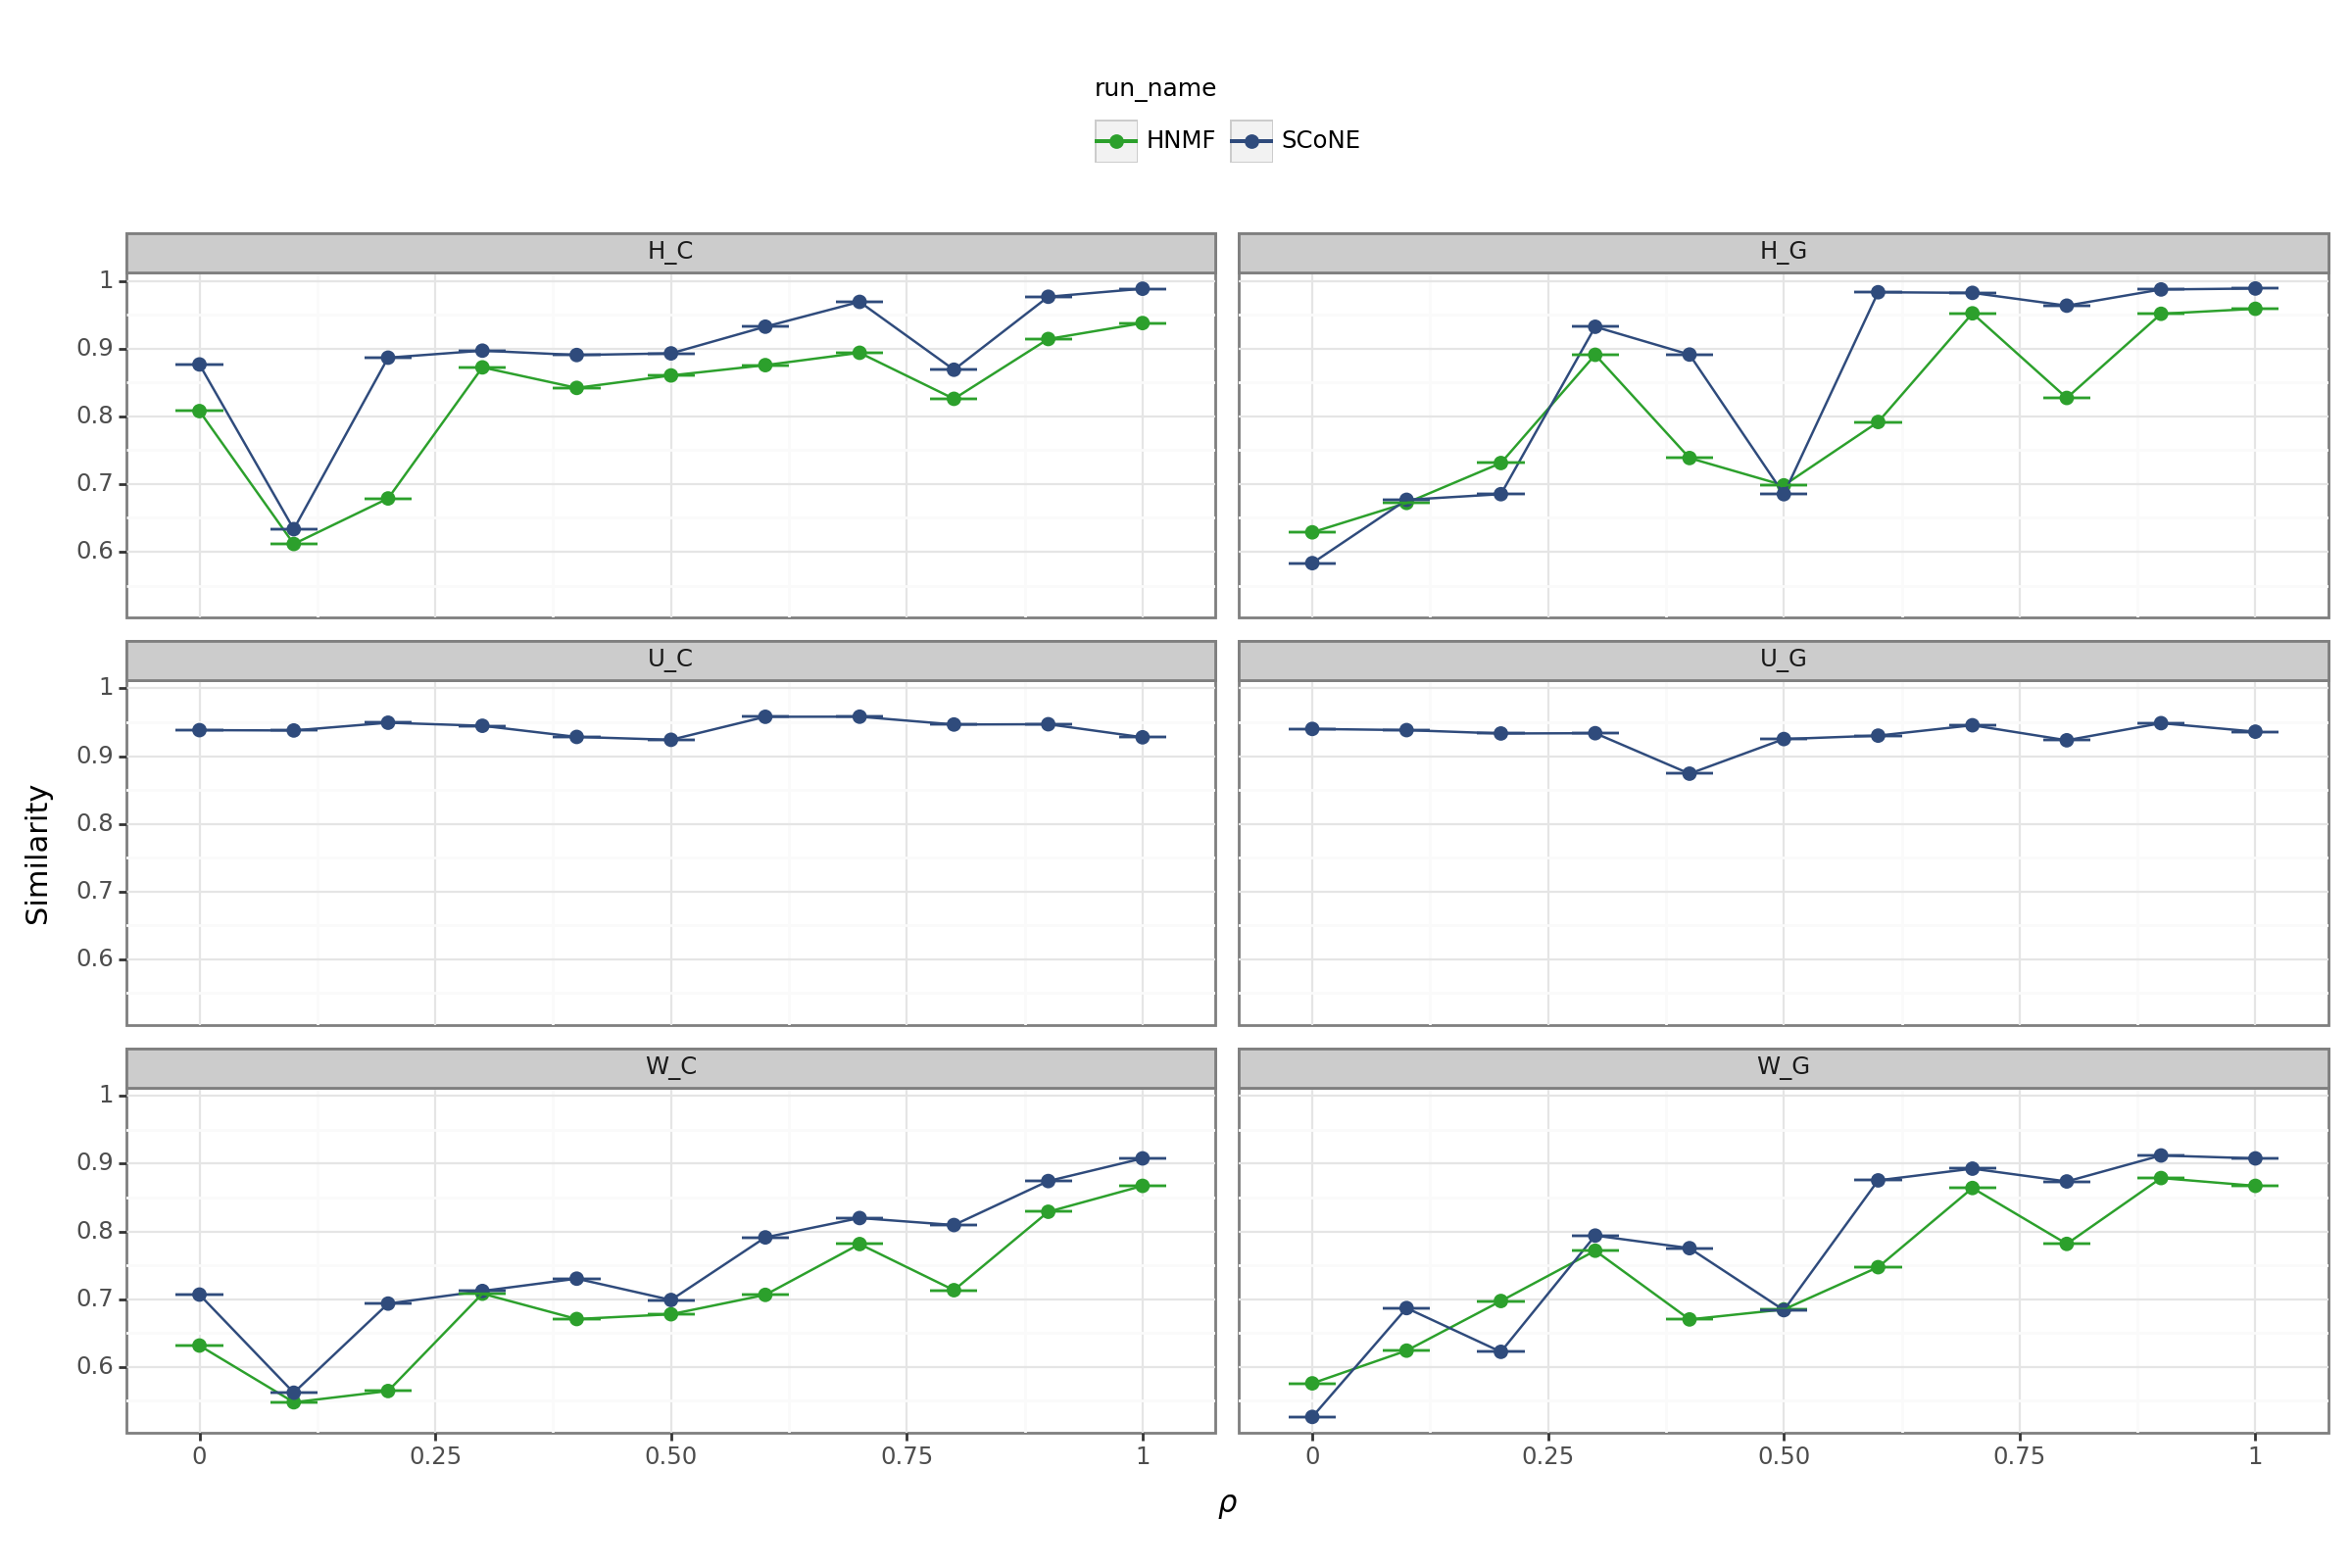

In [3]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"rho",r'$\rho$')

# Assess runs over ZU weight

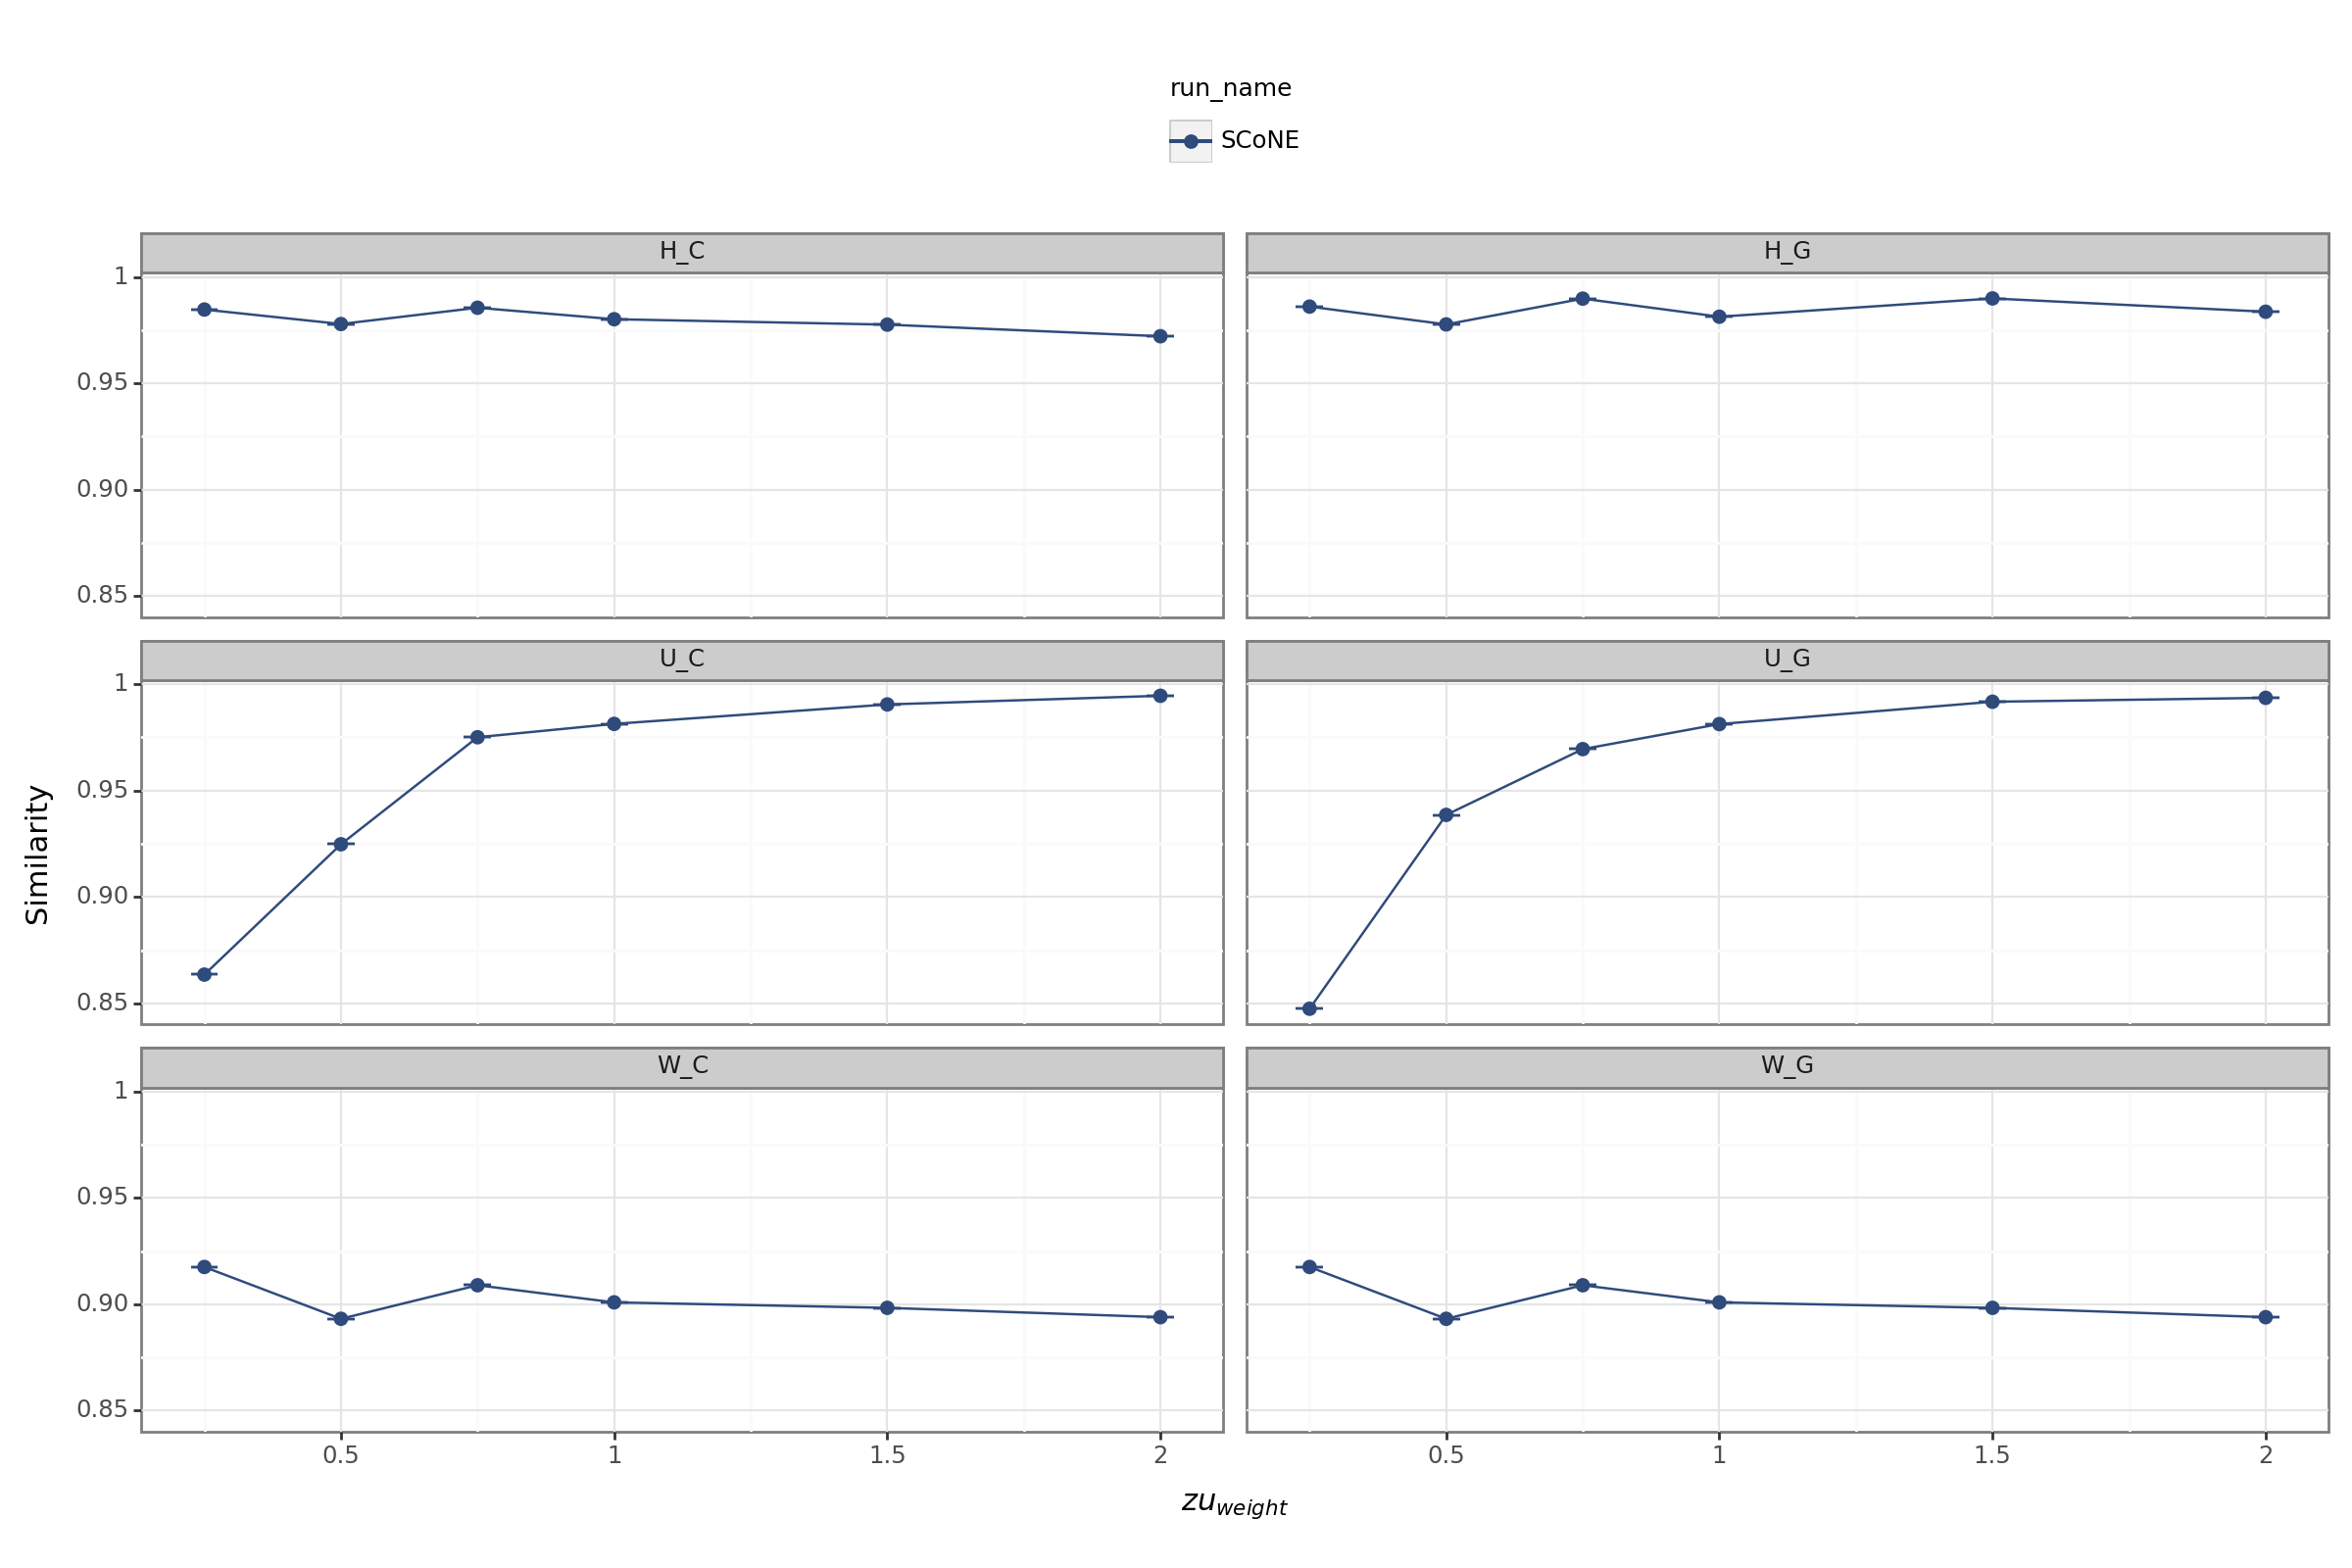

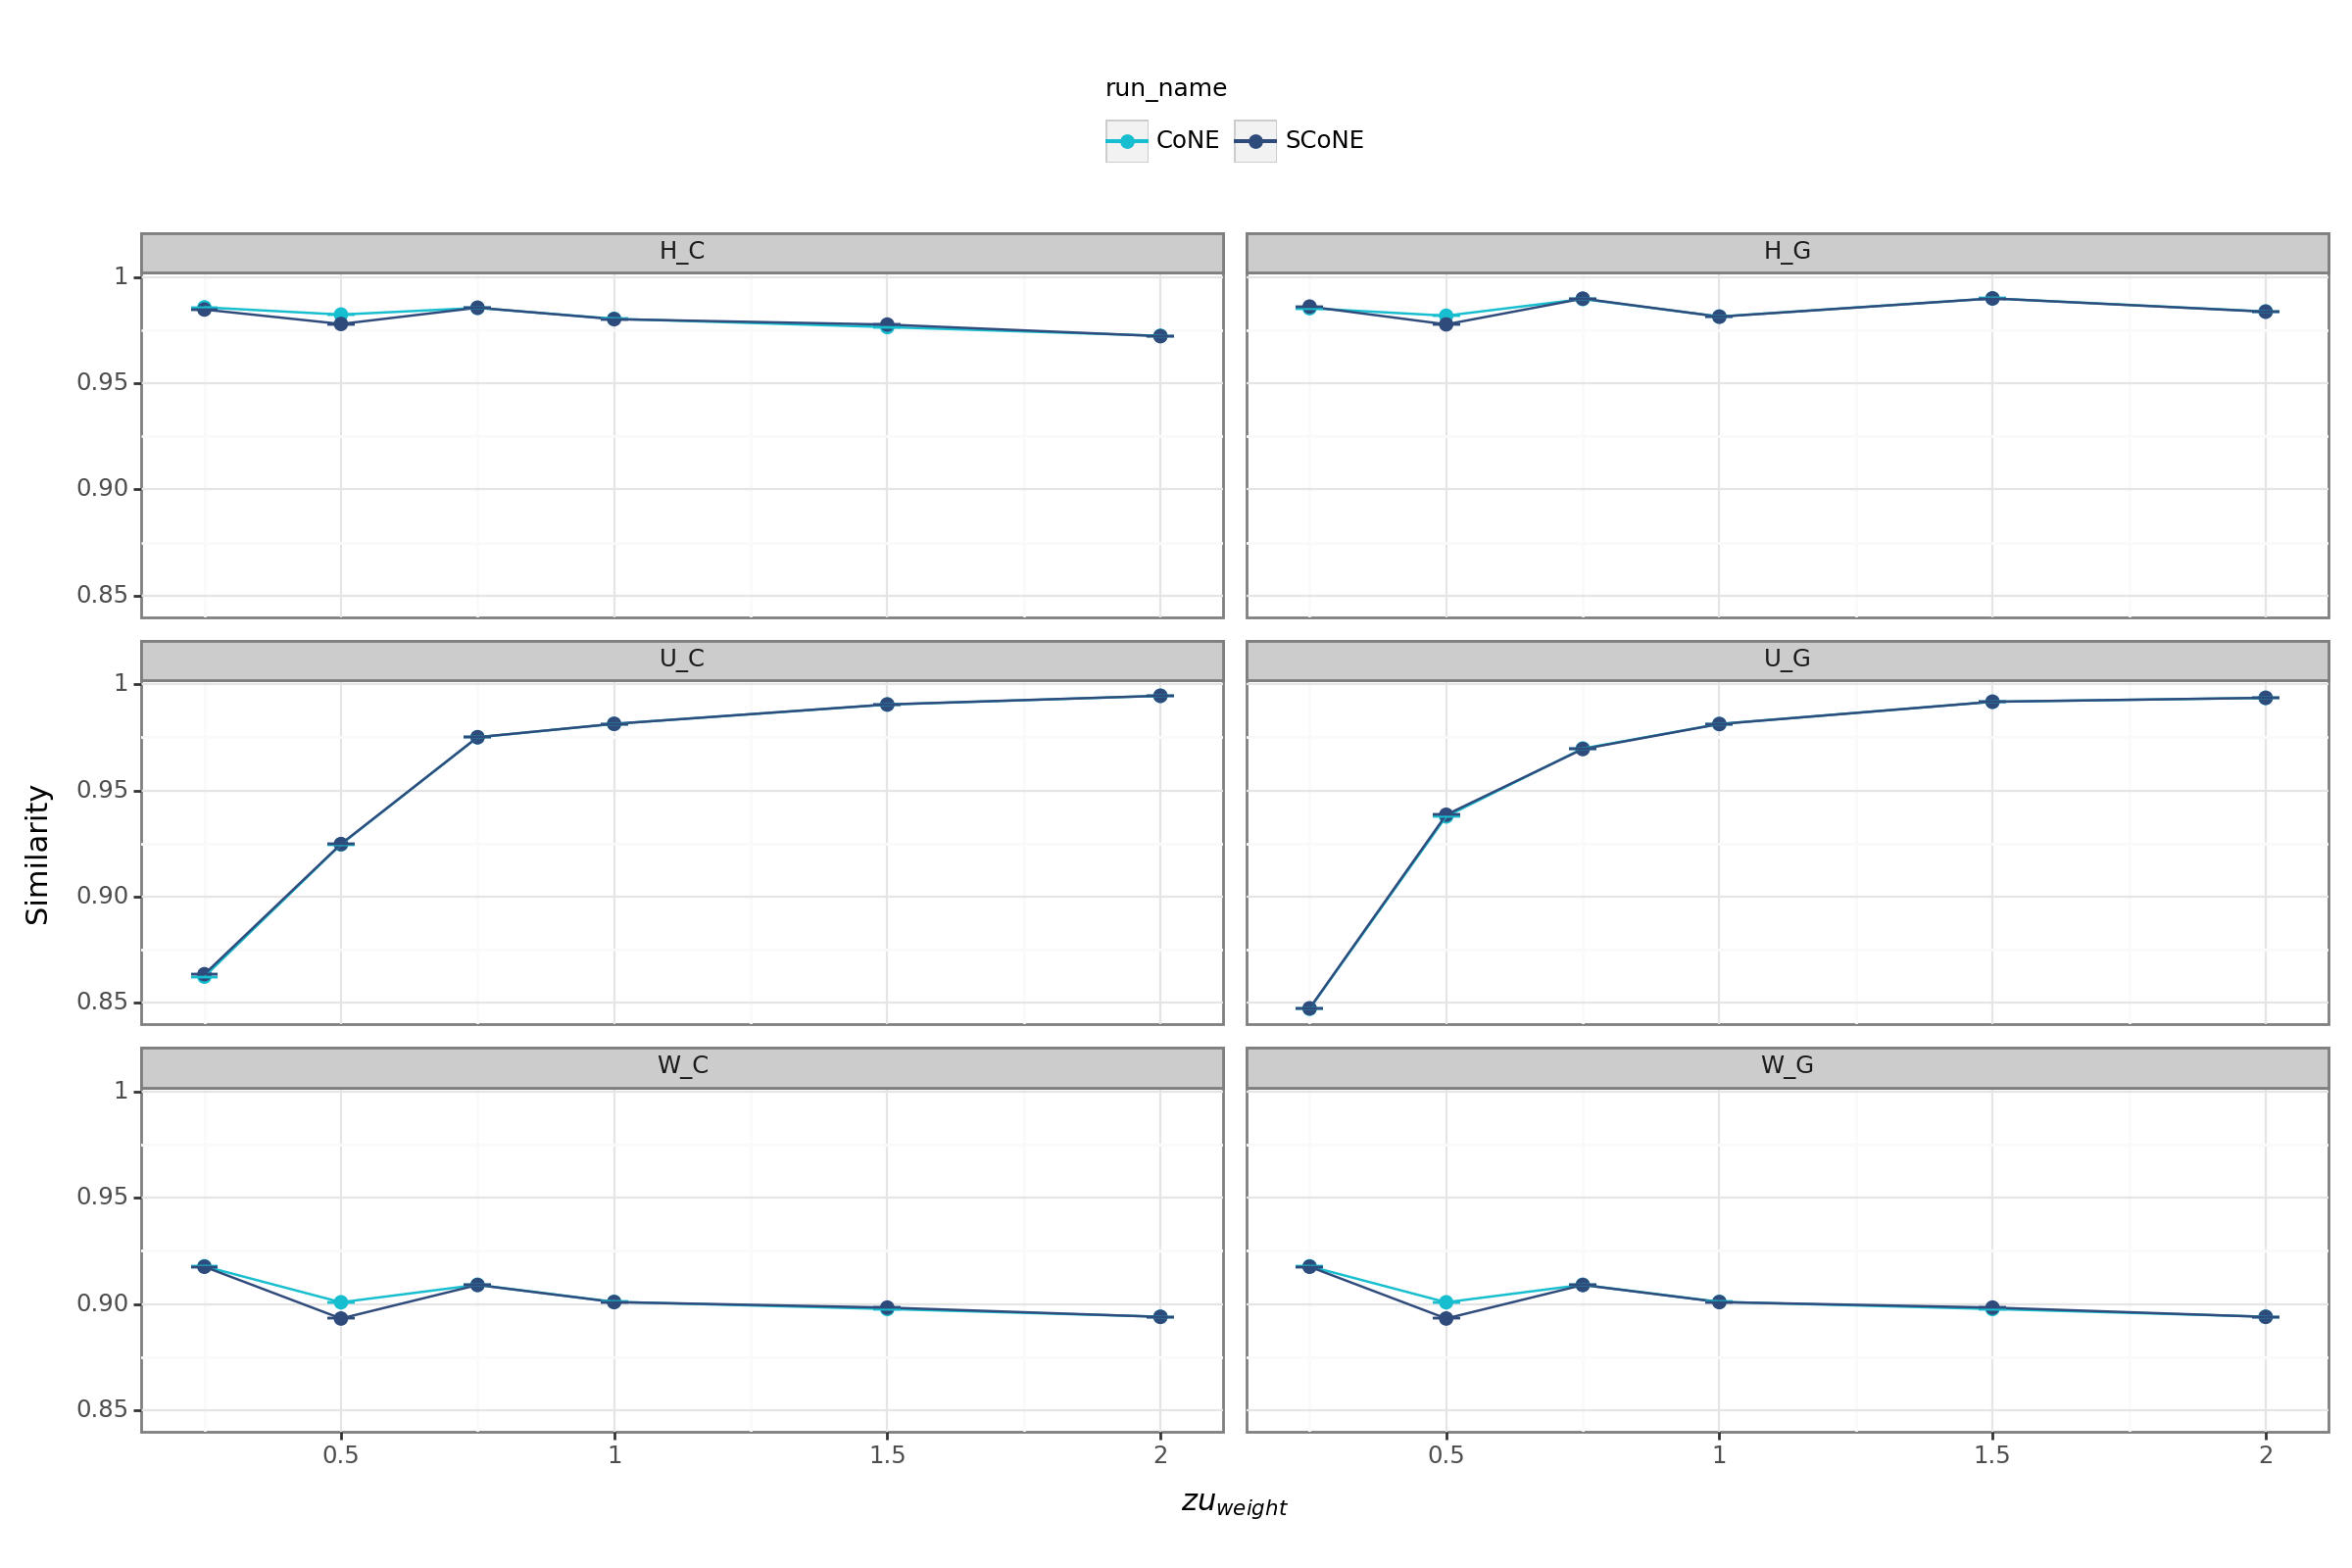

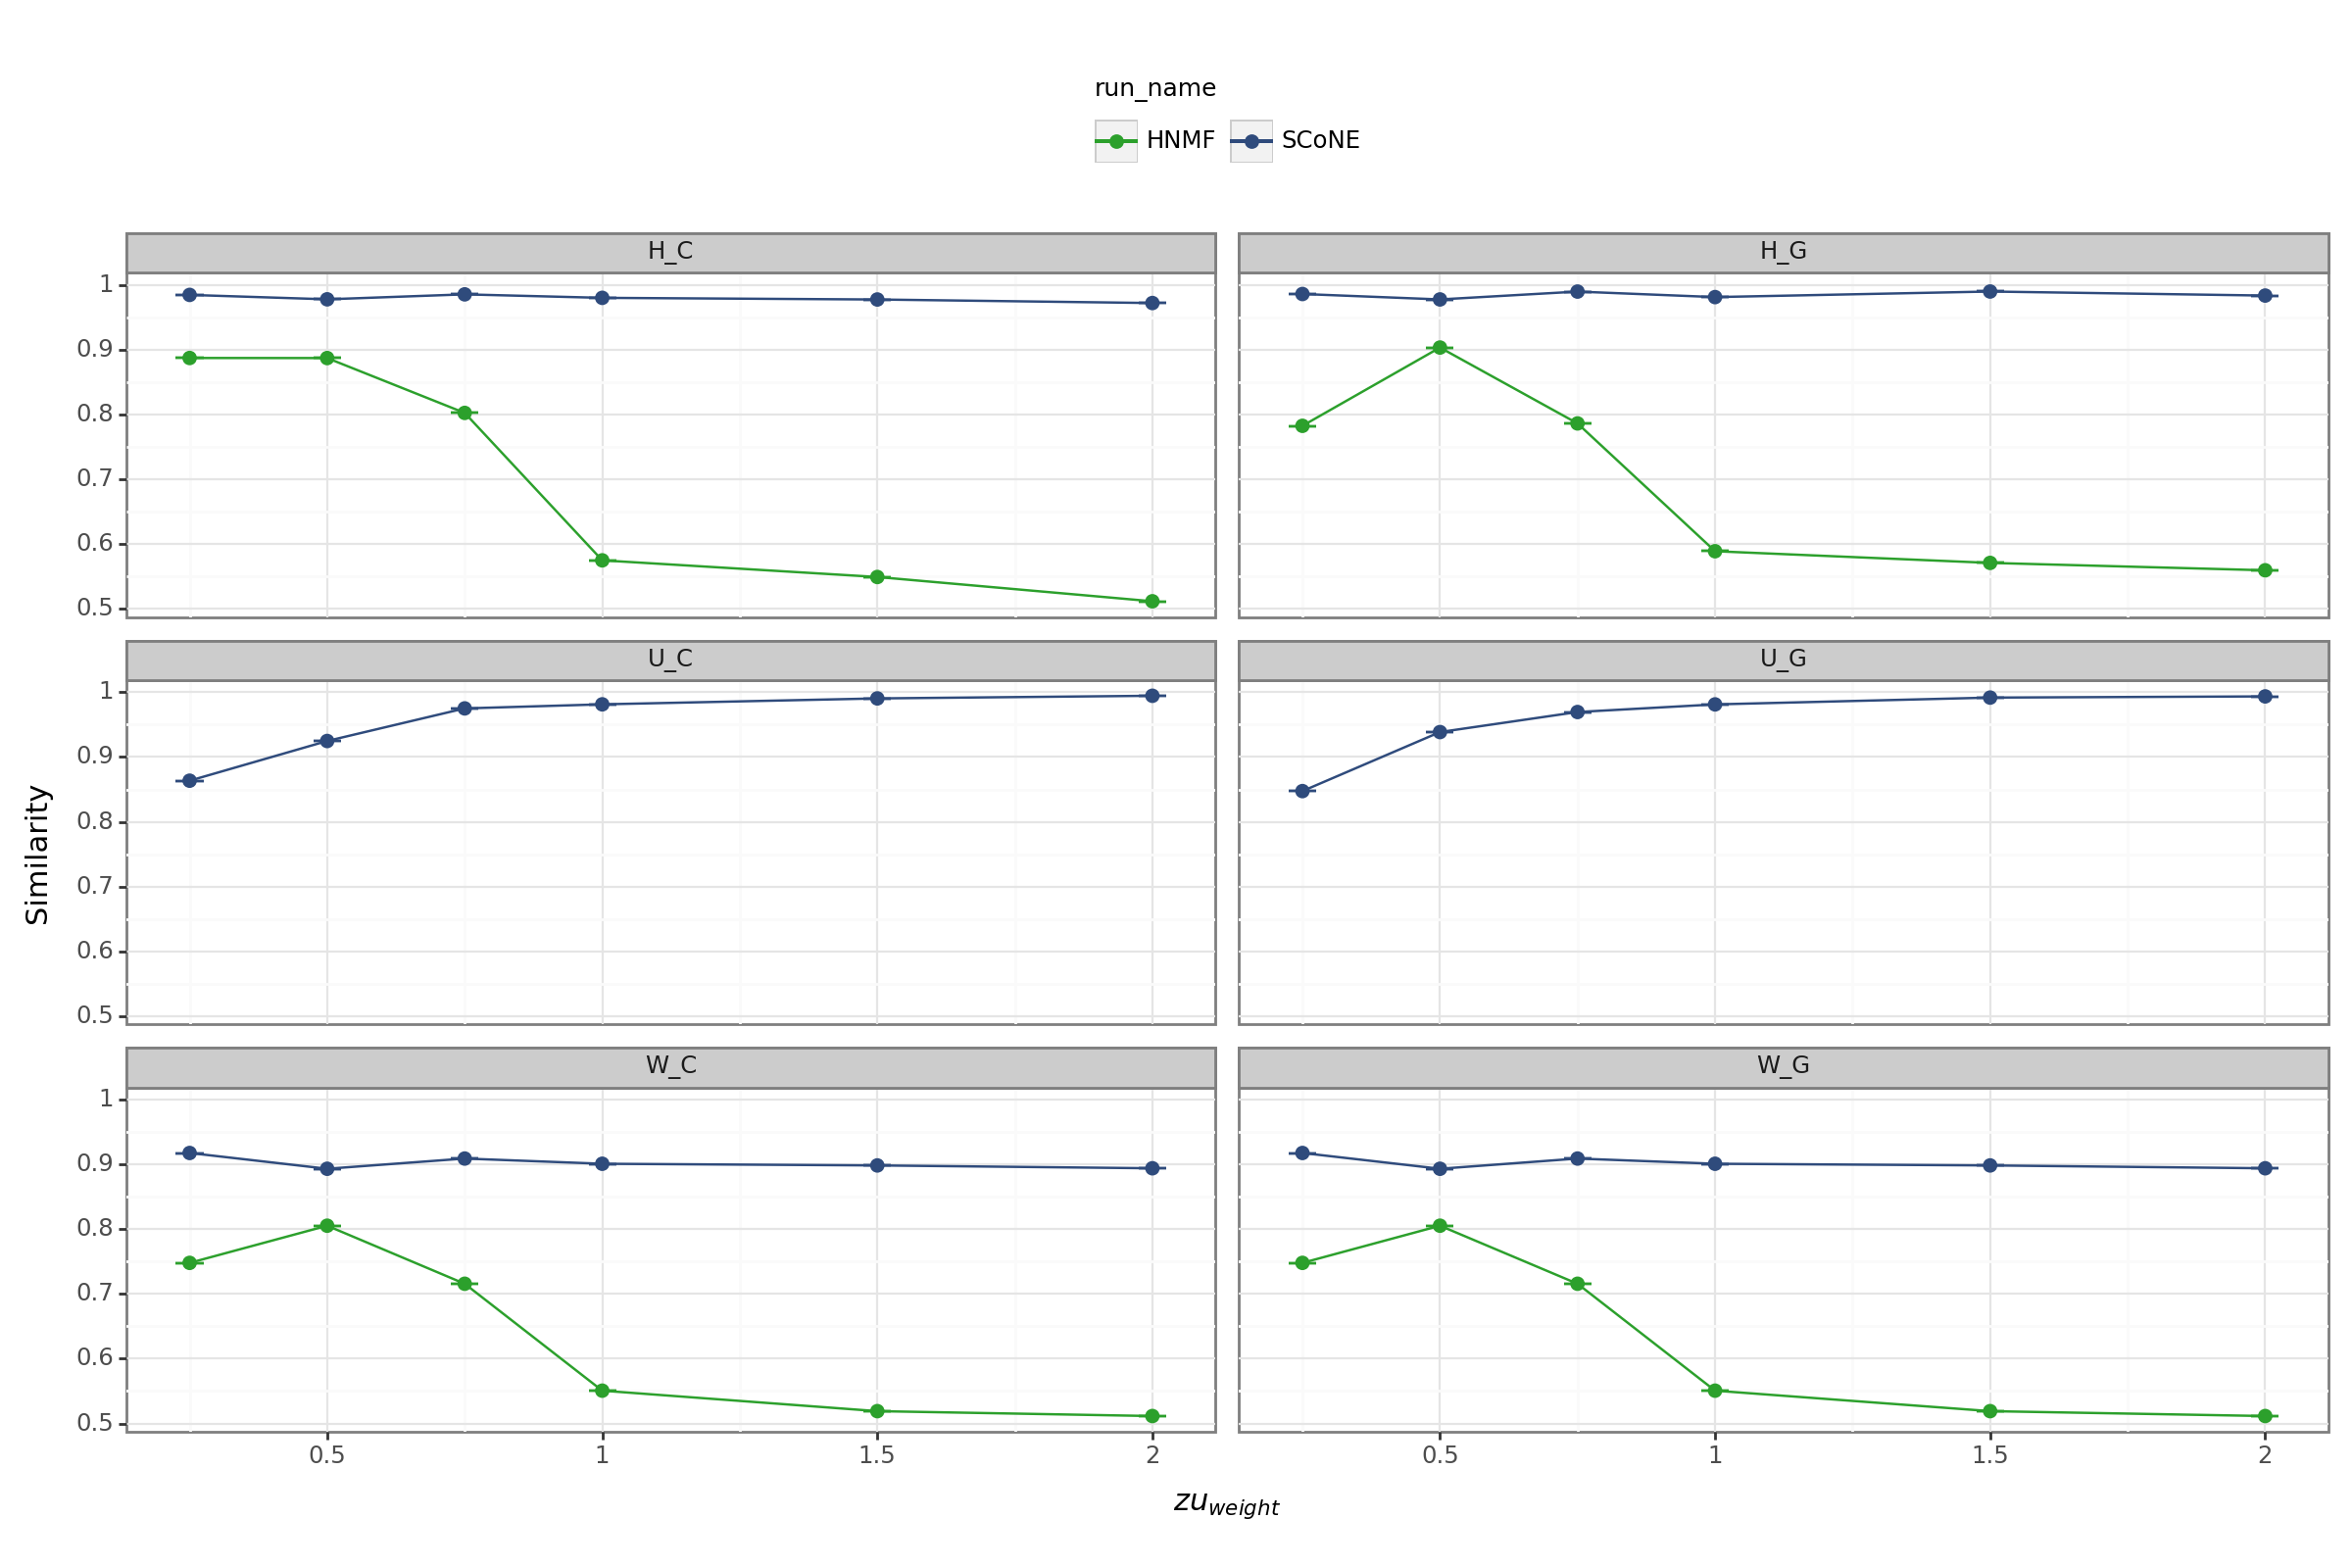

In [4]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/zu_weight_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"ZU_weight",r'$zu_{weight}$')

# Assess runs over noise

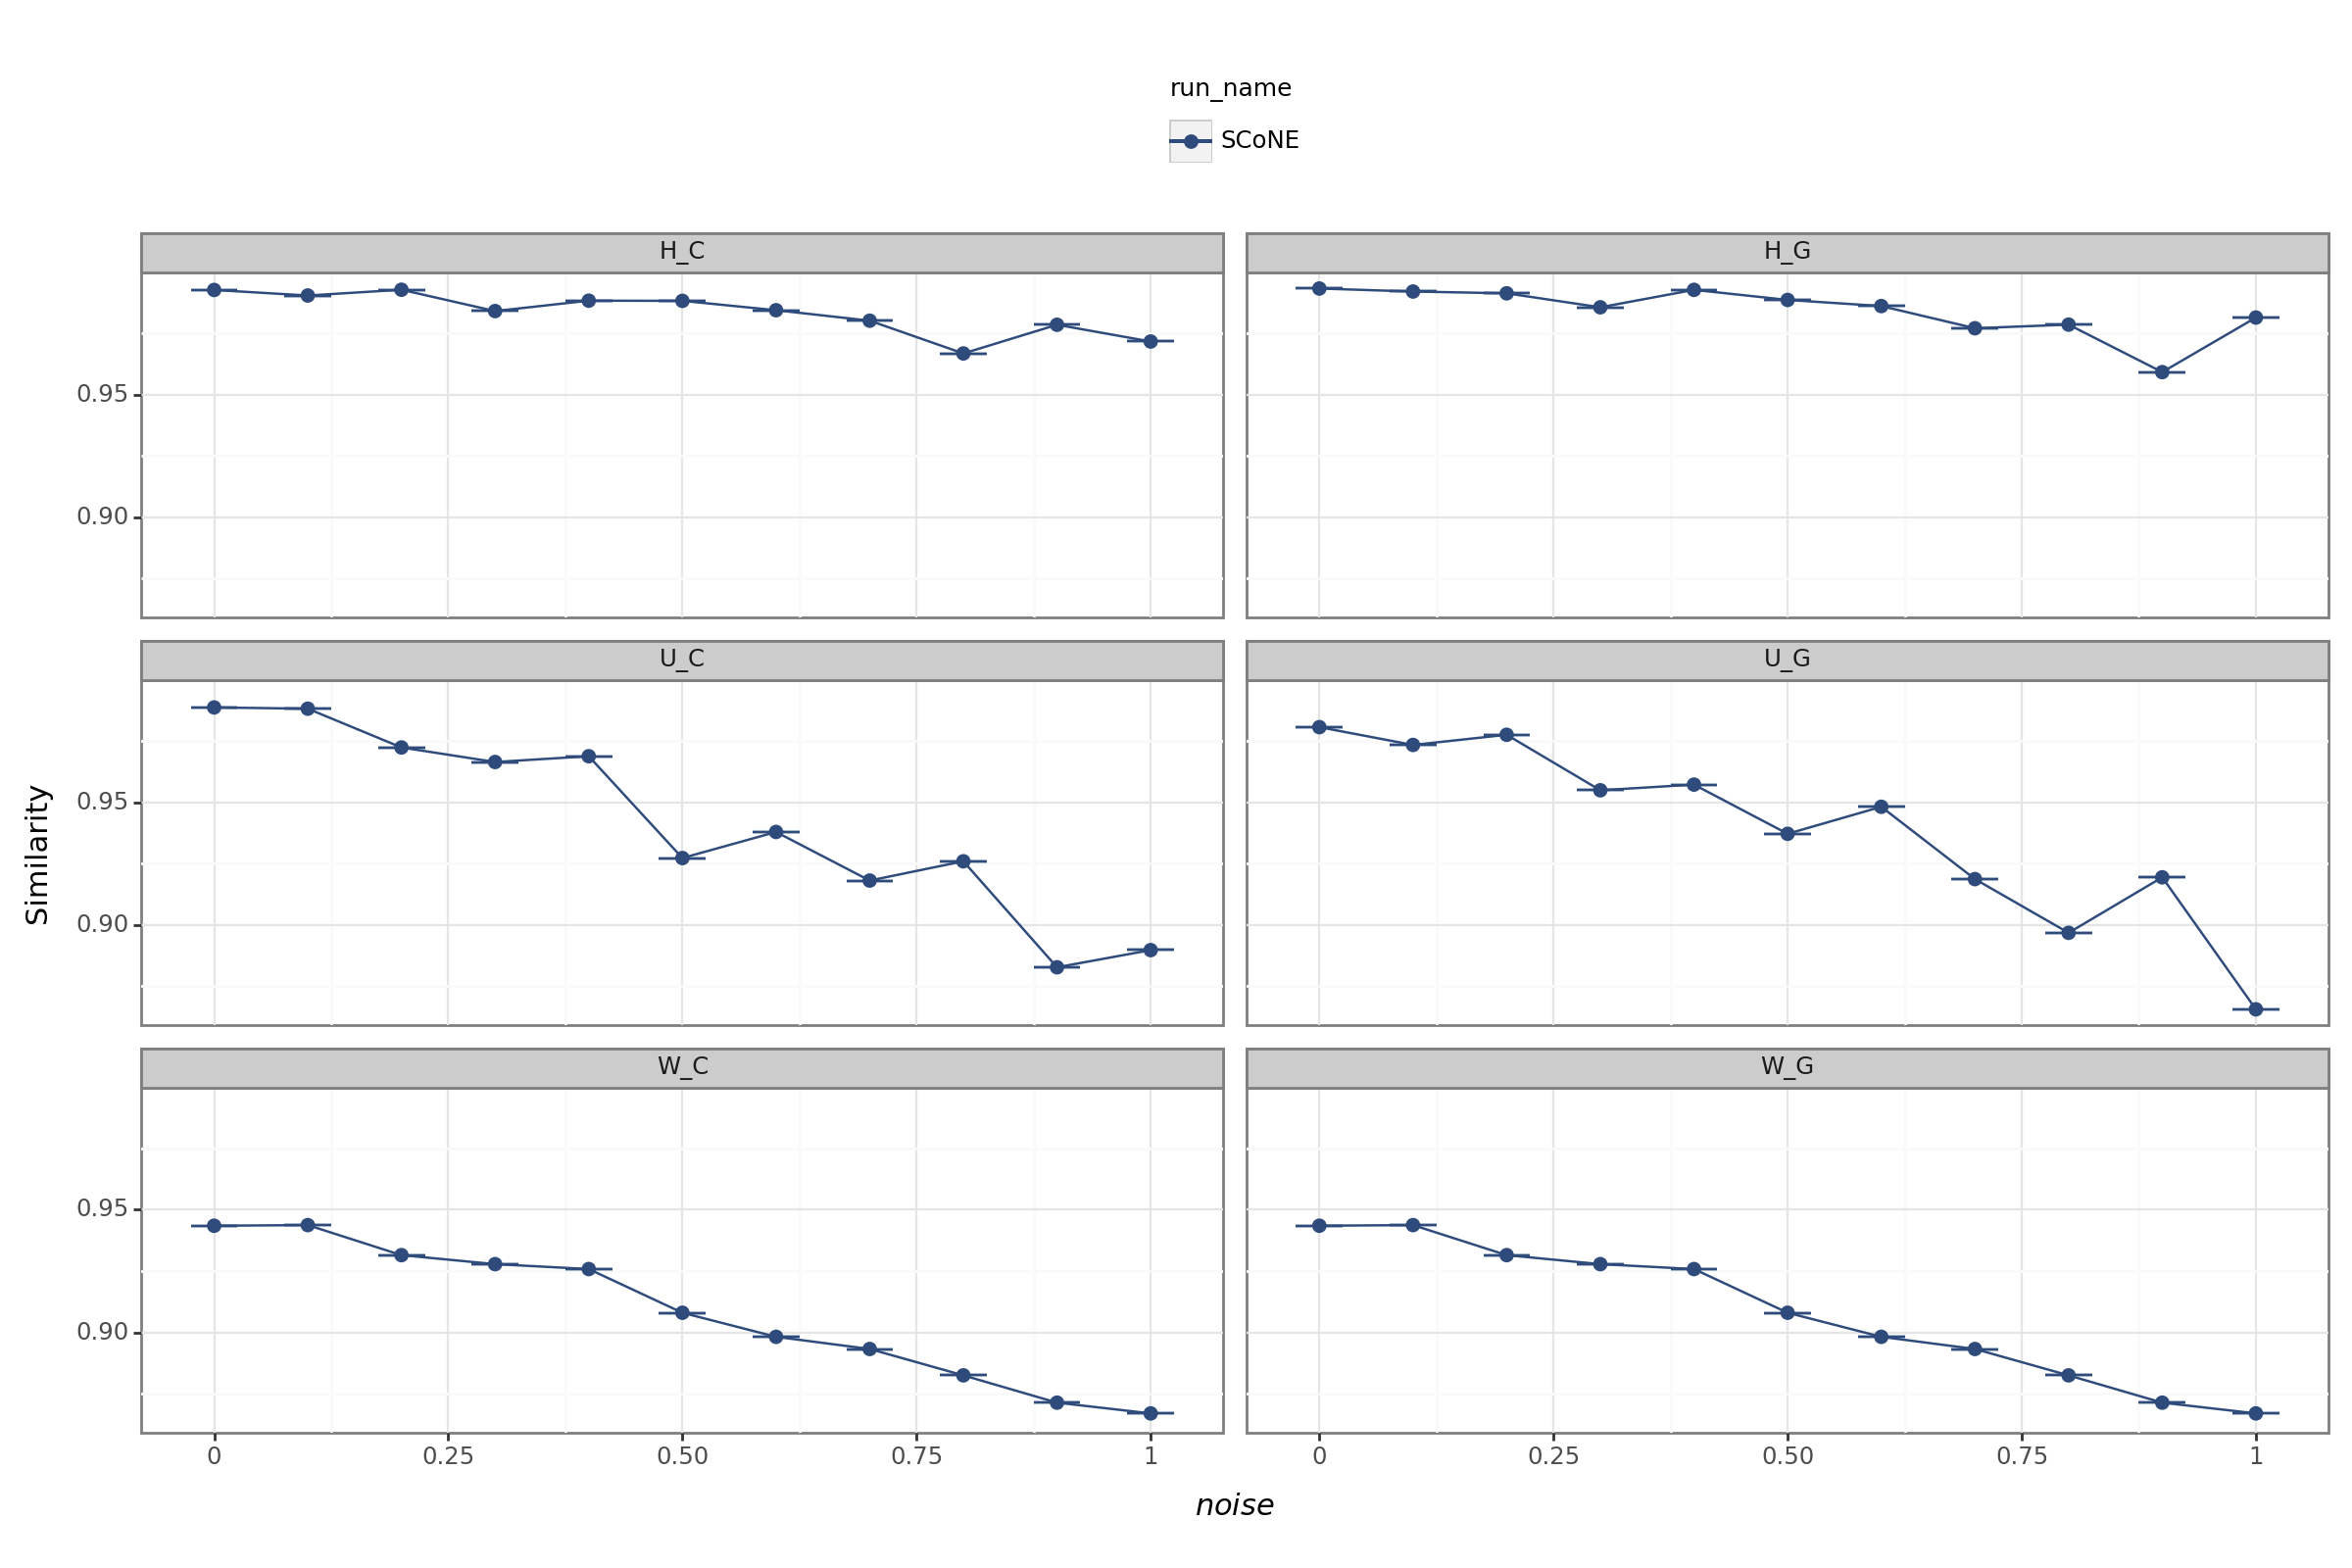

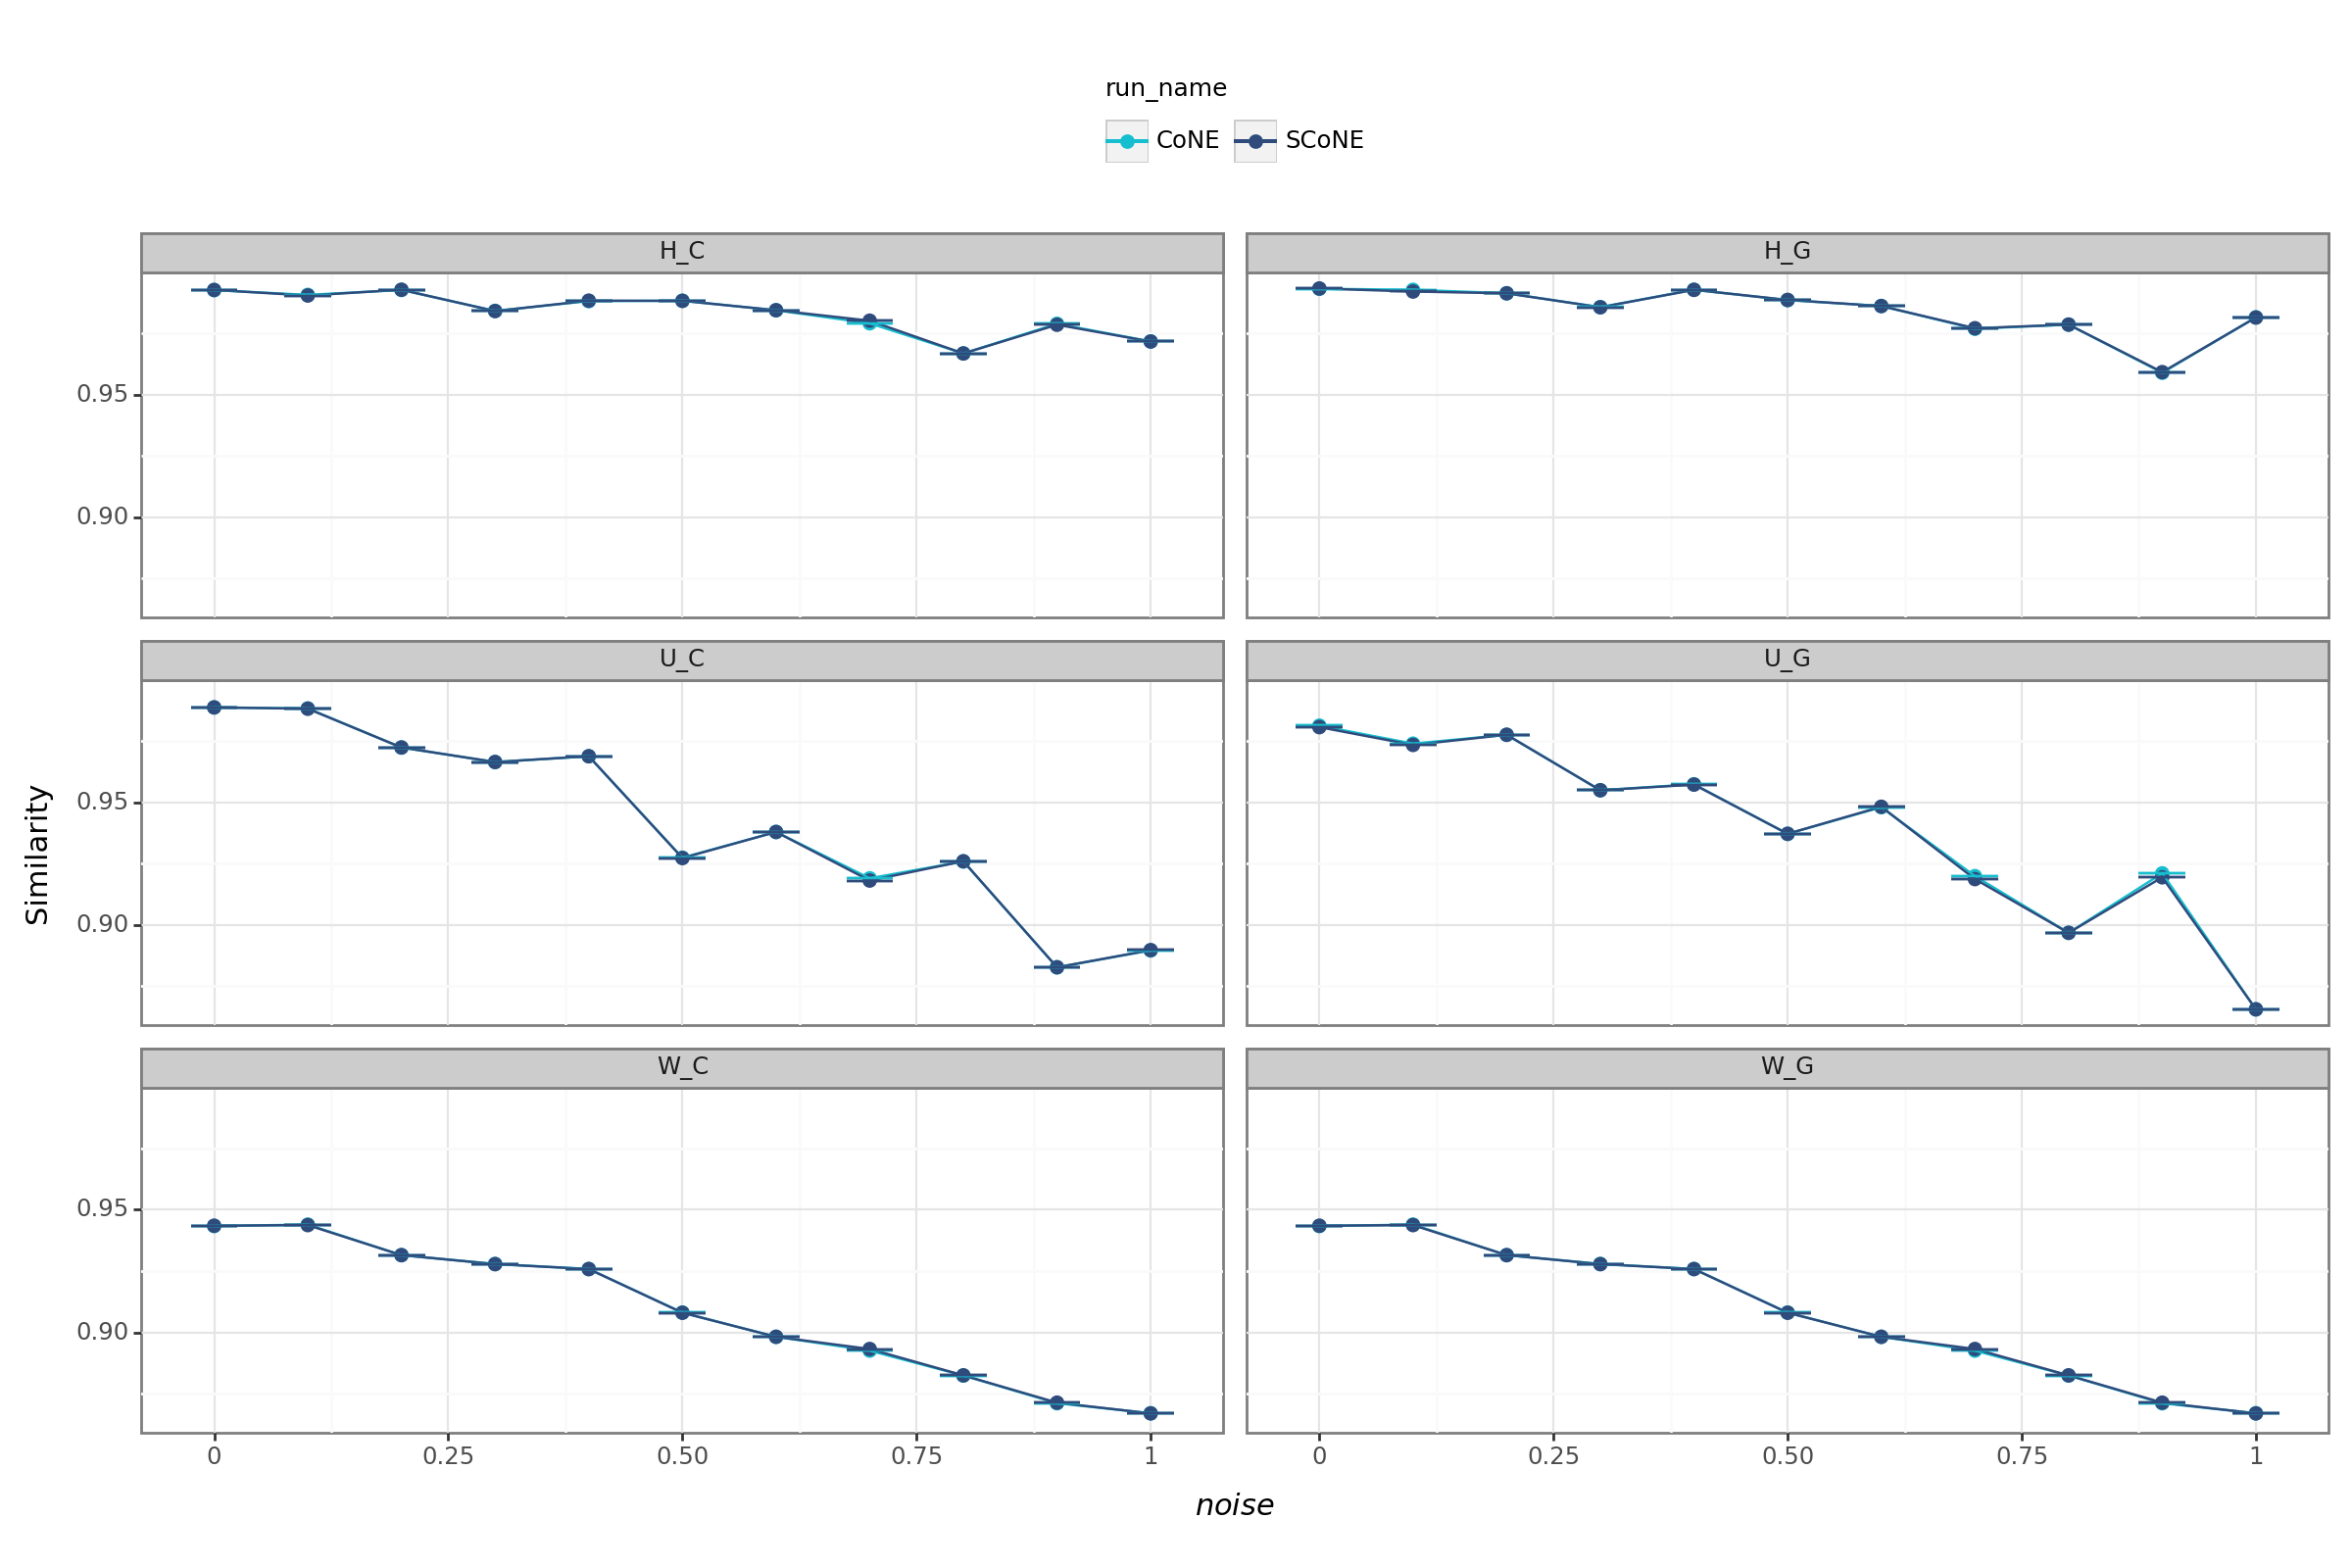

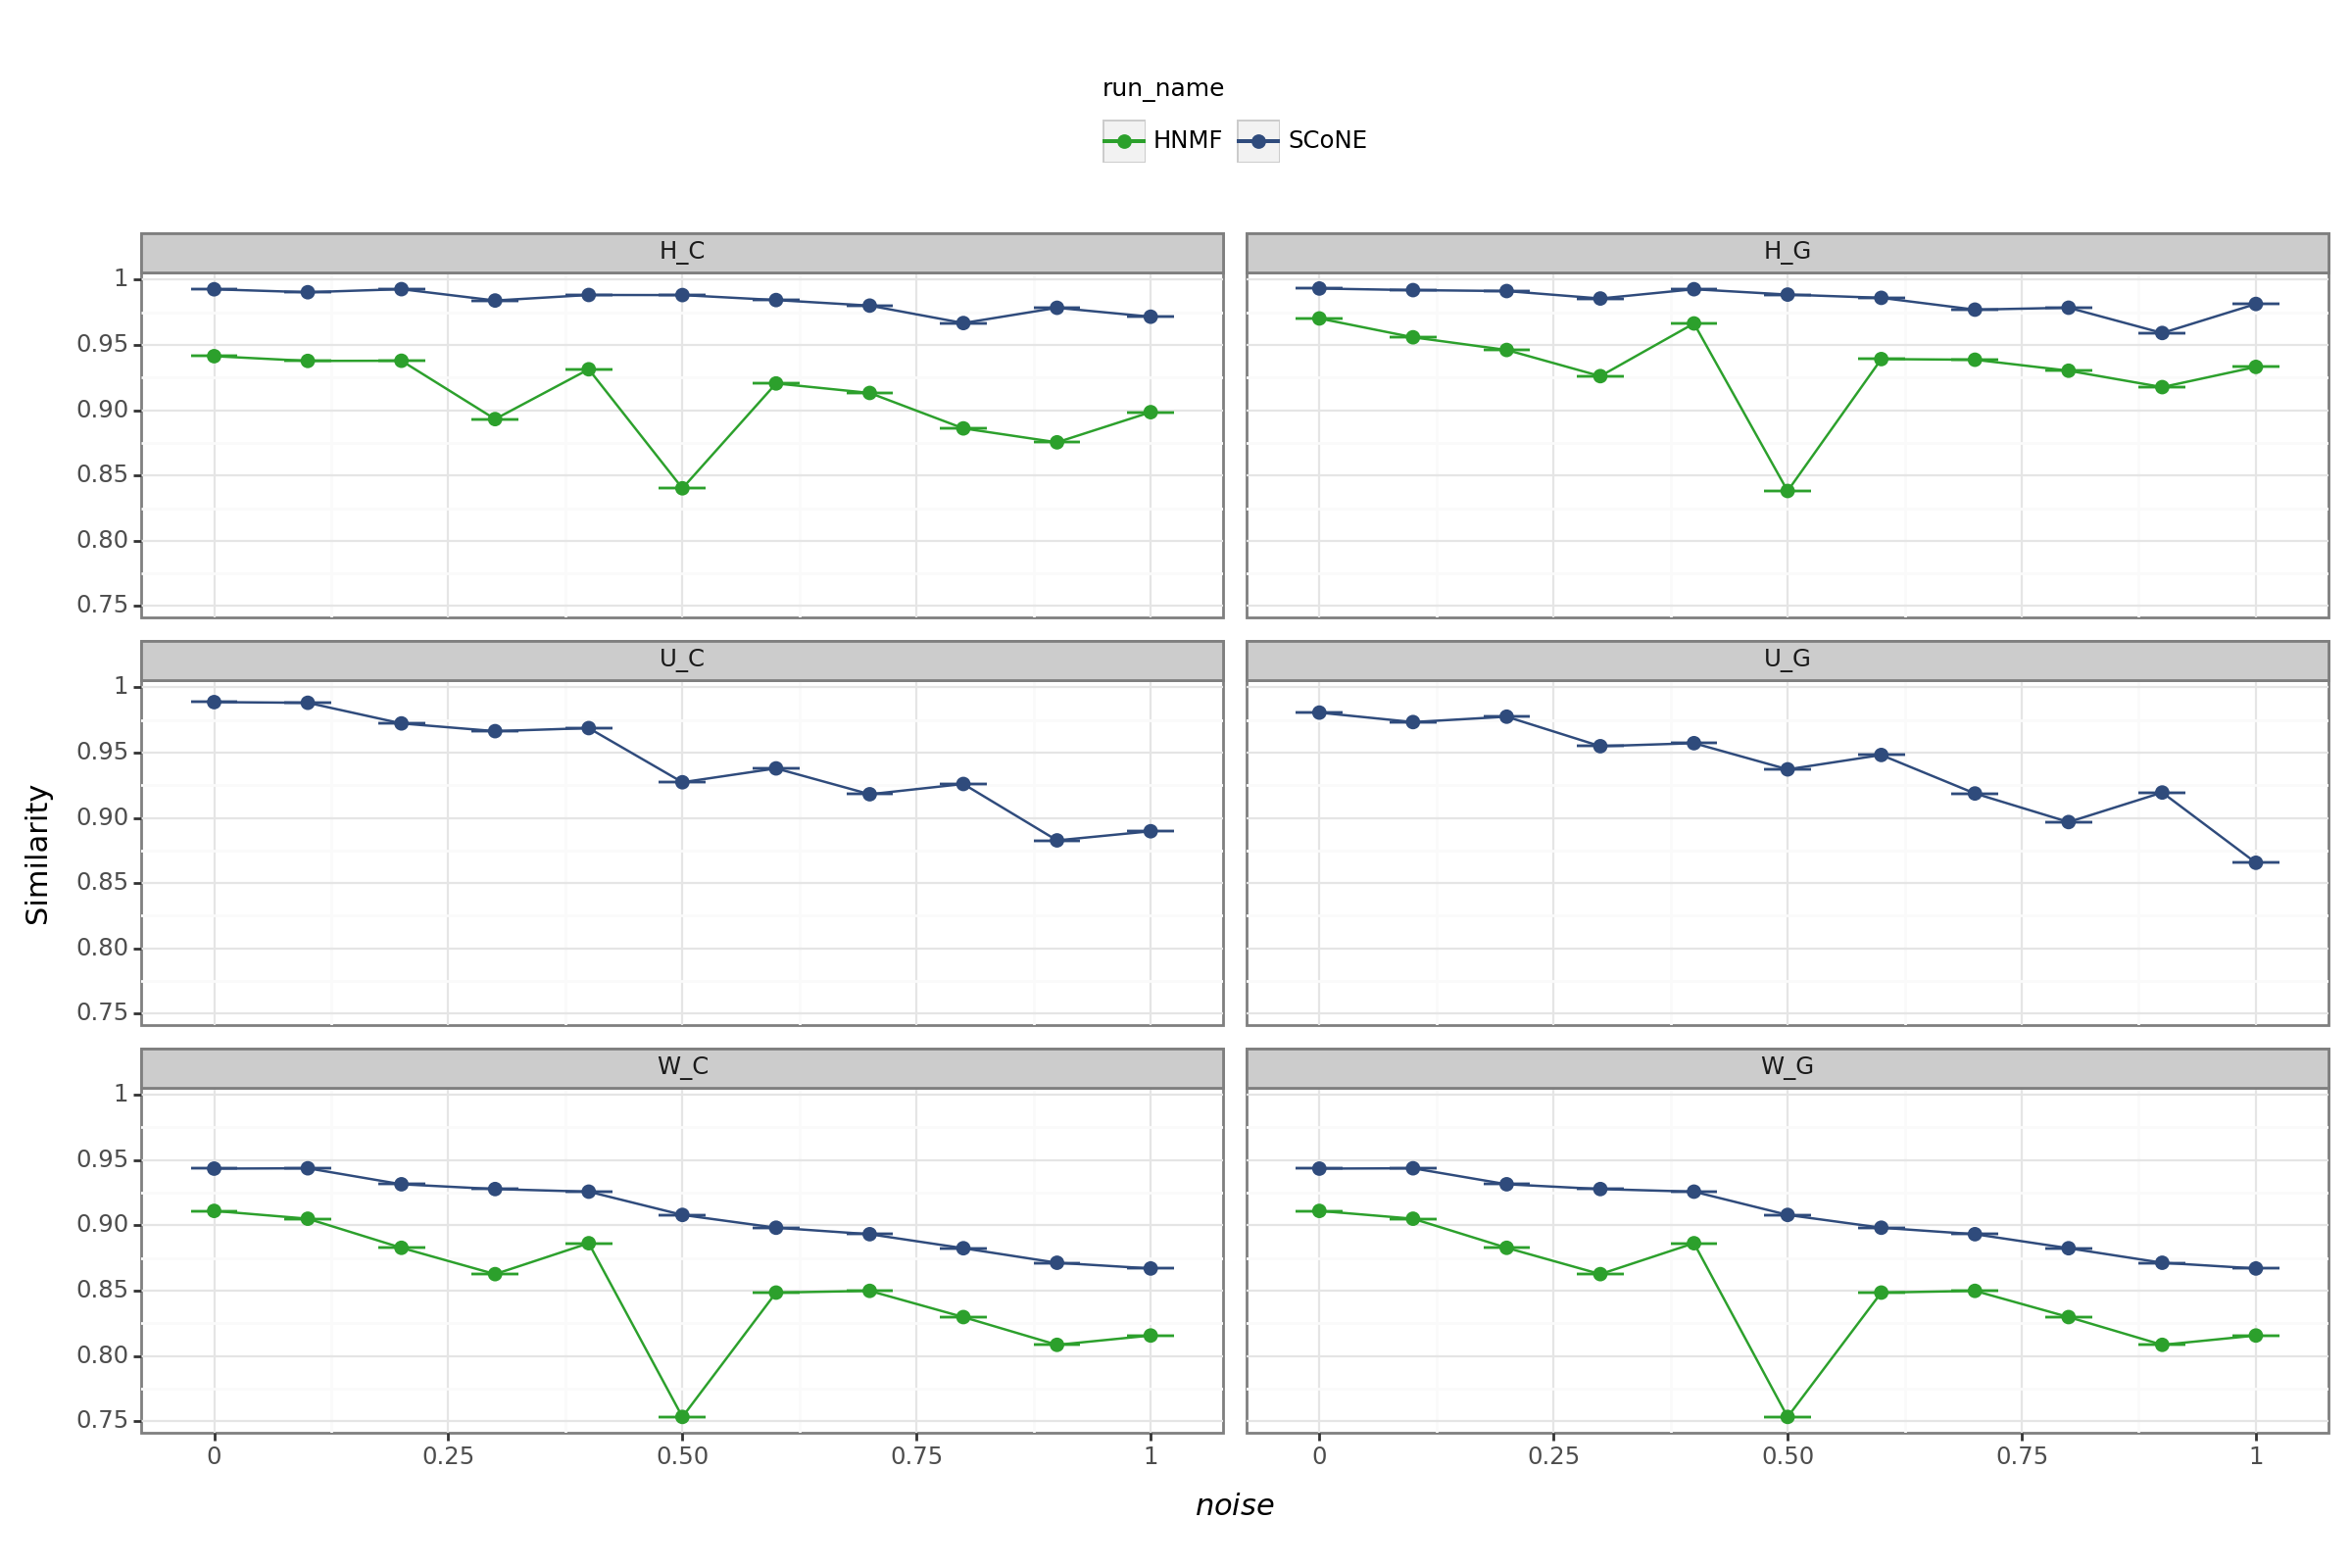

In [5]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"noise",r'$noise$')

# Assess runs over sparsity

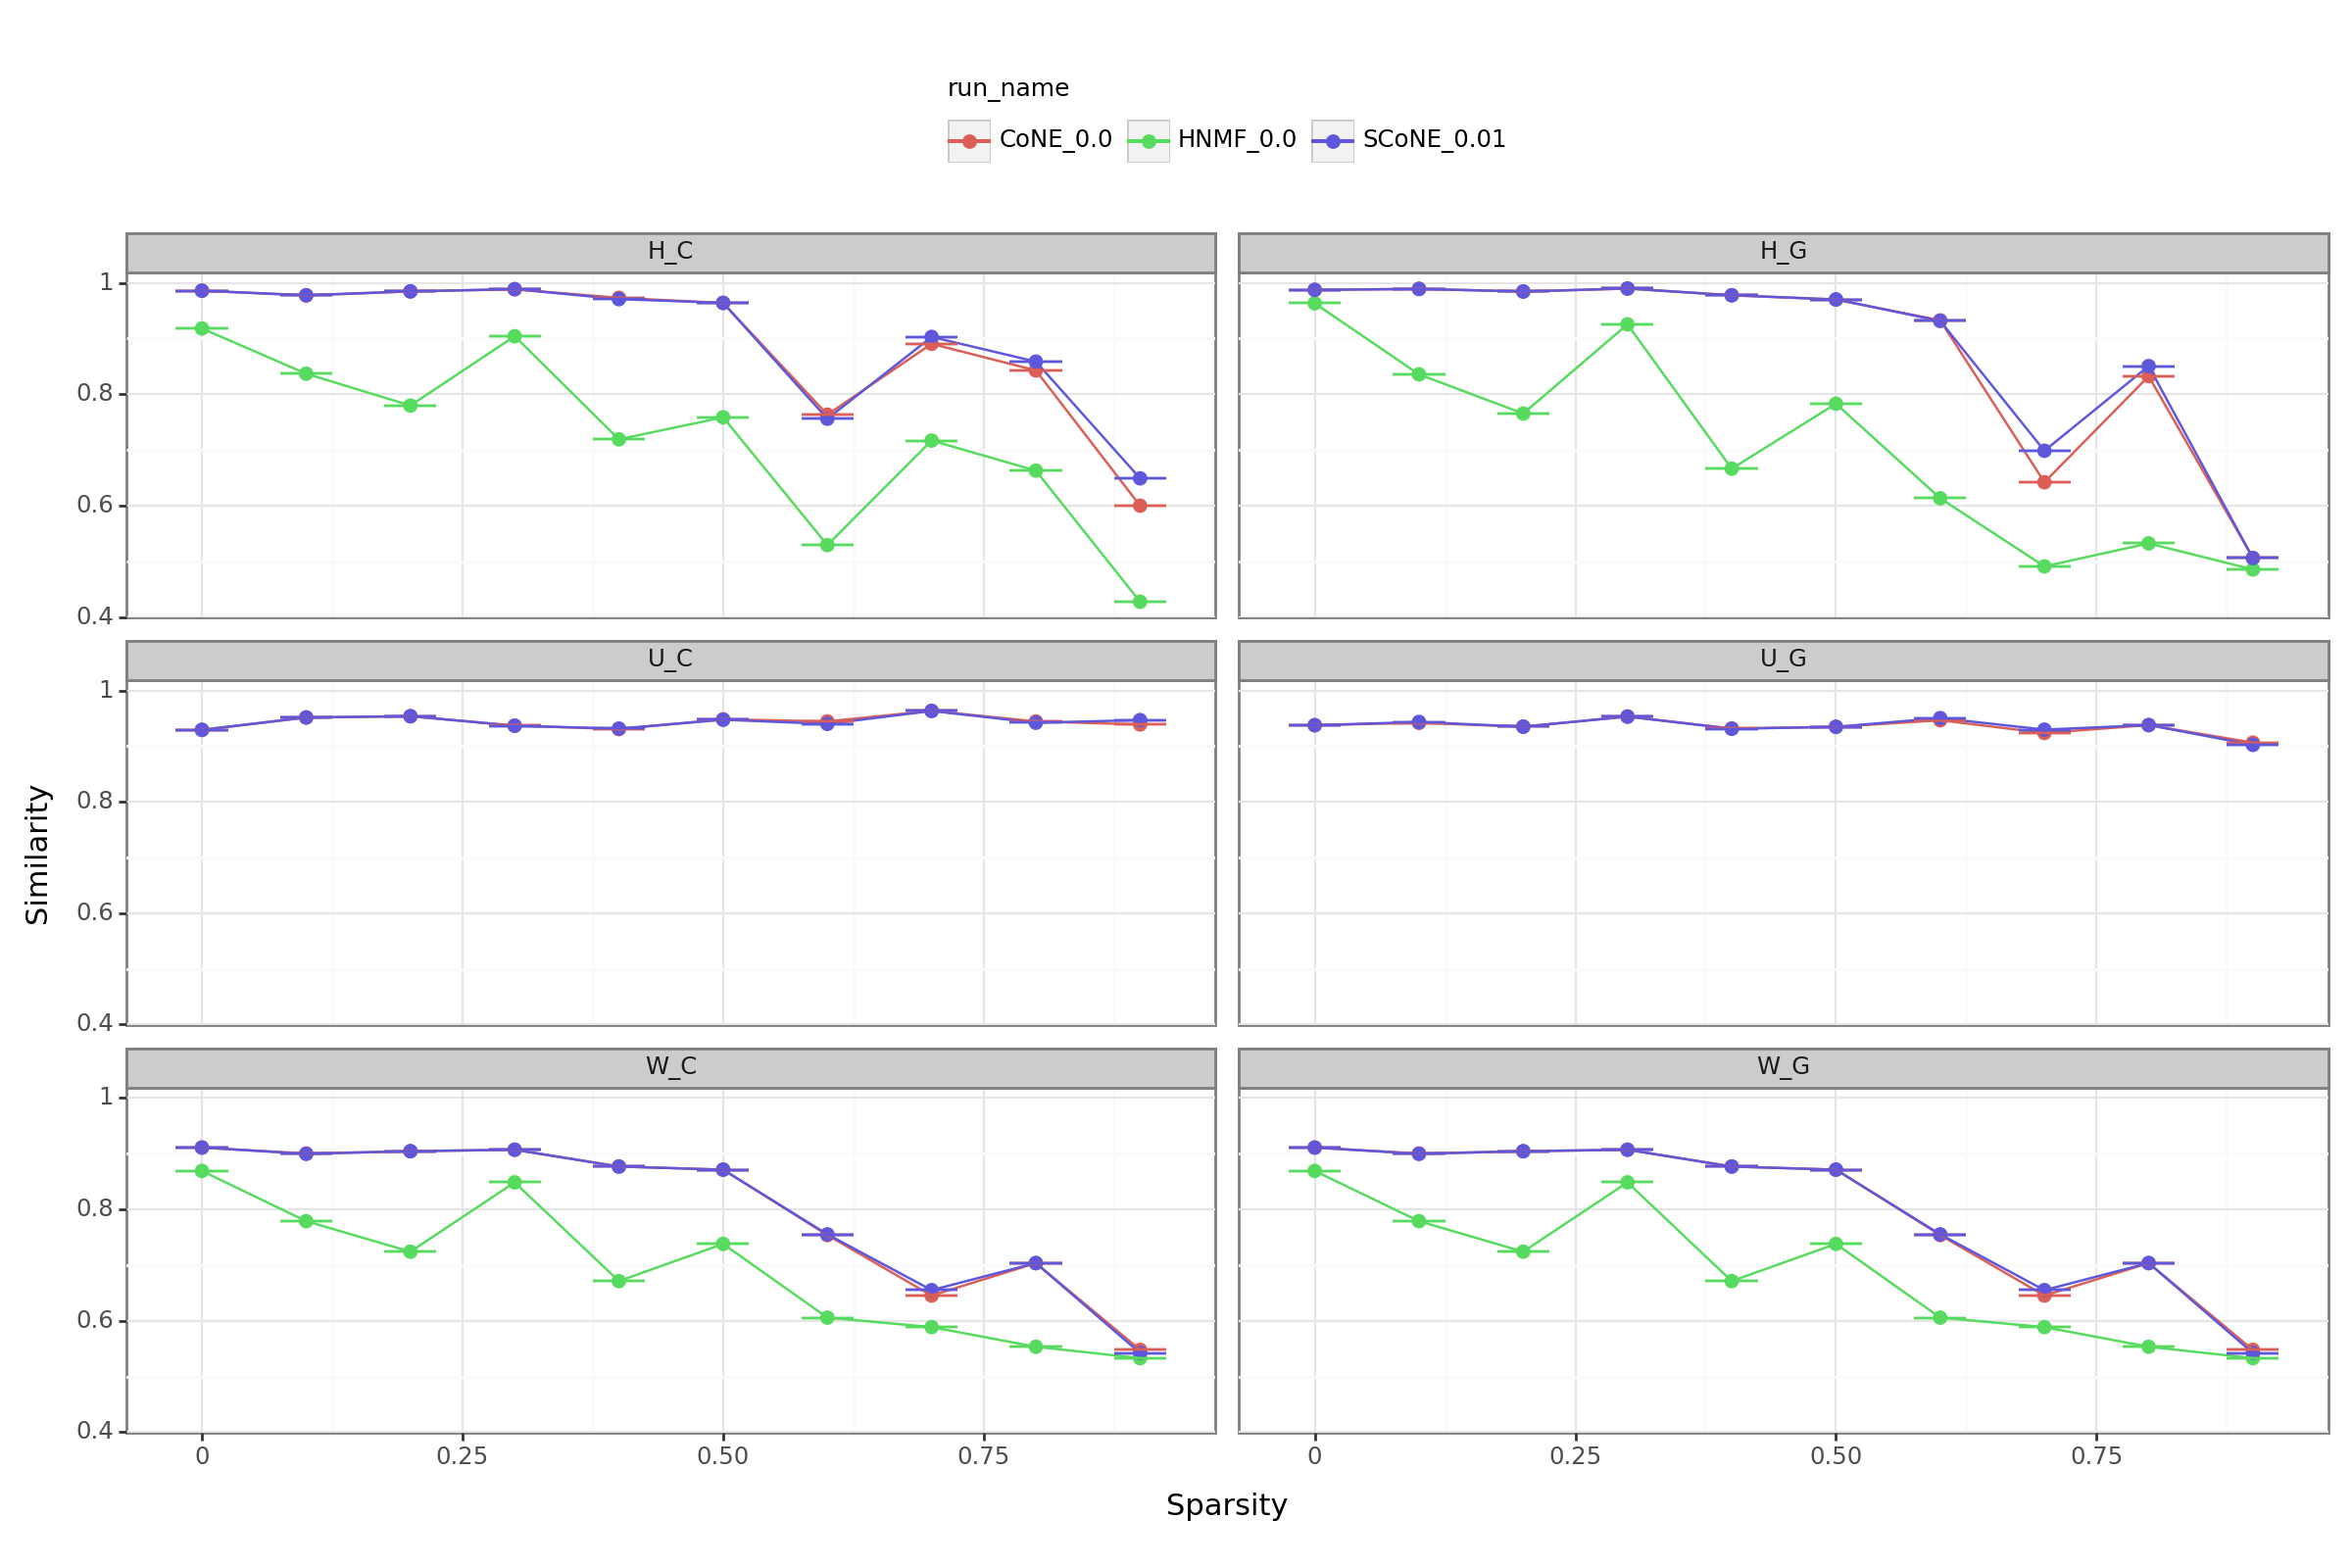

In [89]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_sim.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
p = (
    ggplot(summary, aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + facet_wrap('factor_matrix',nrow=3)
    + labs(y='Similarity',x="Sparsity")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

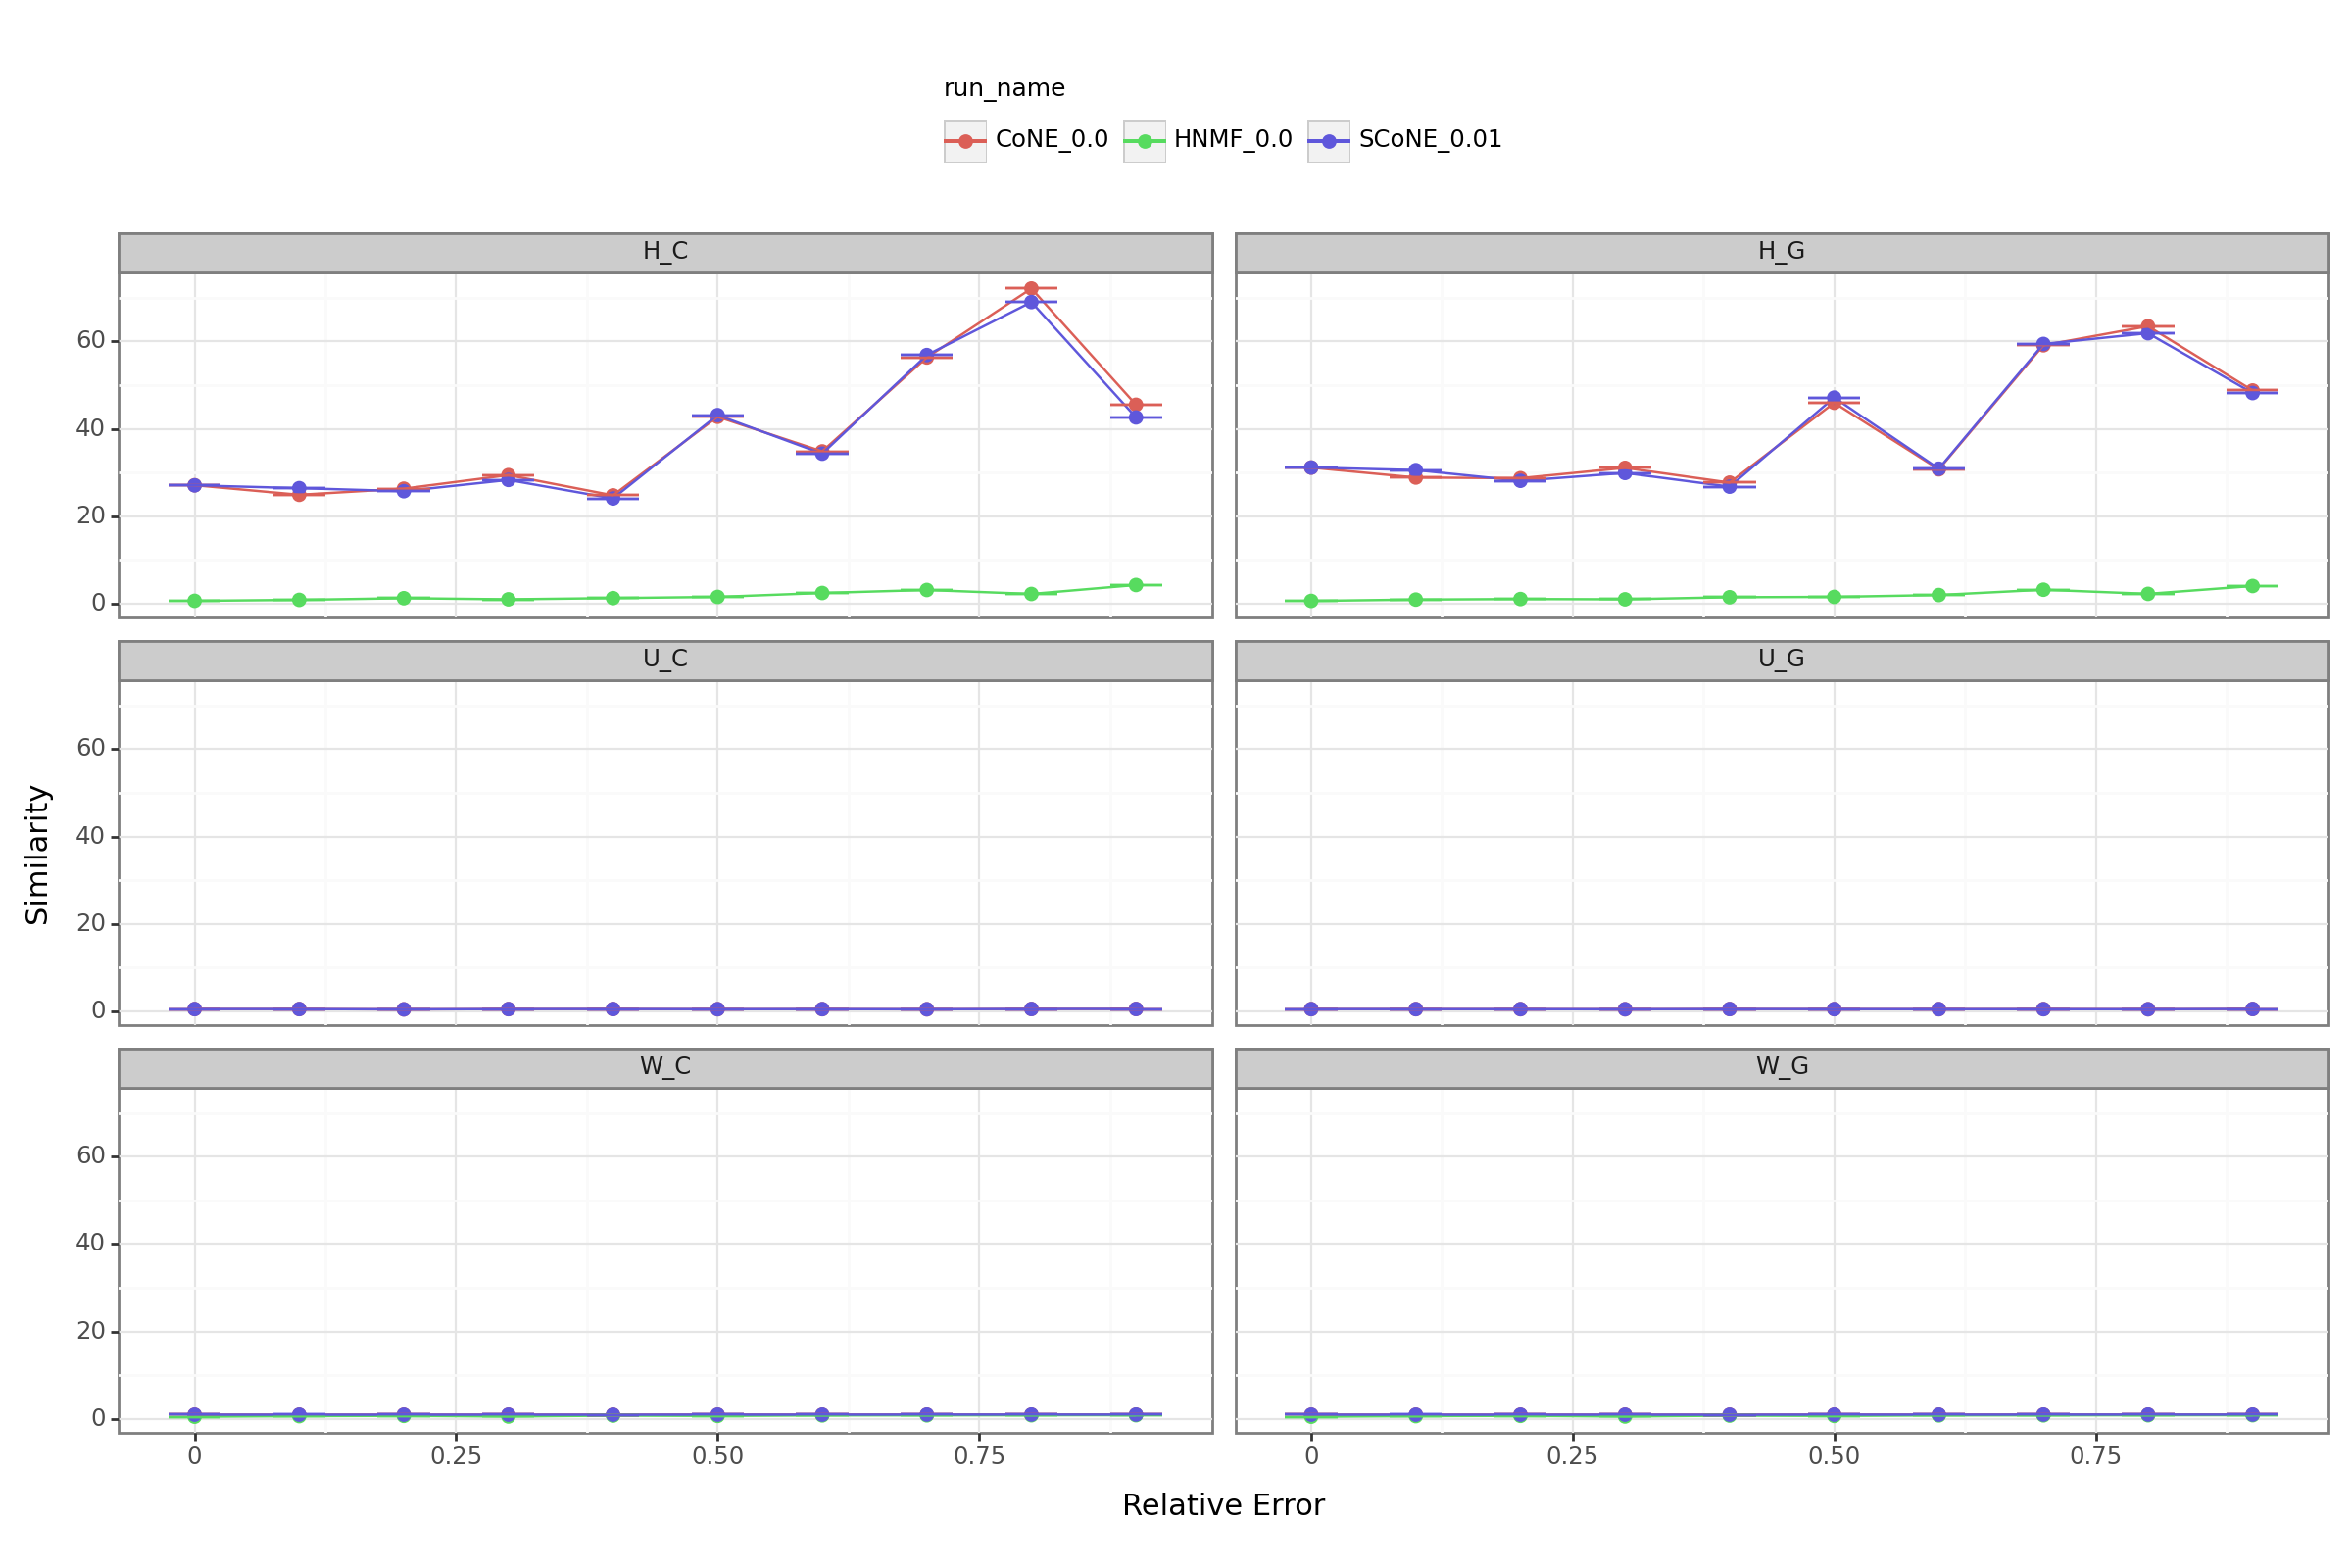

In [90]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_rel_error.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
p = (
    ggplot(summary, aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + facet_wrap('factor_matrix',nrow=3)
    + labs(y='Similarity',x="Relative Error")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

This plot for H_G and H_C tells the story we want

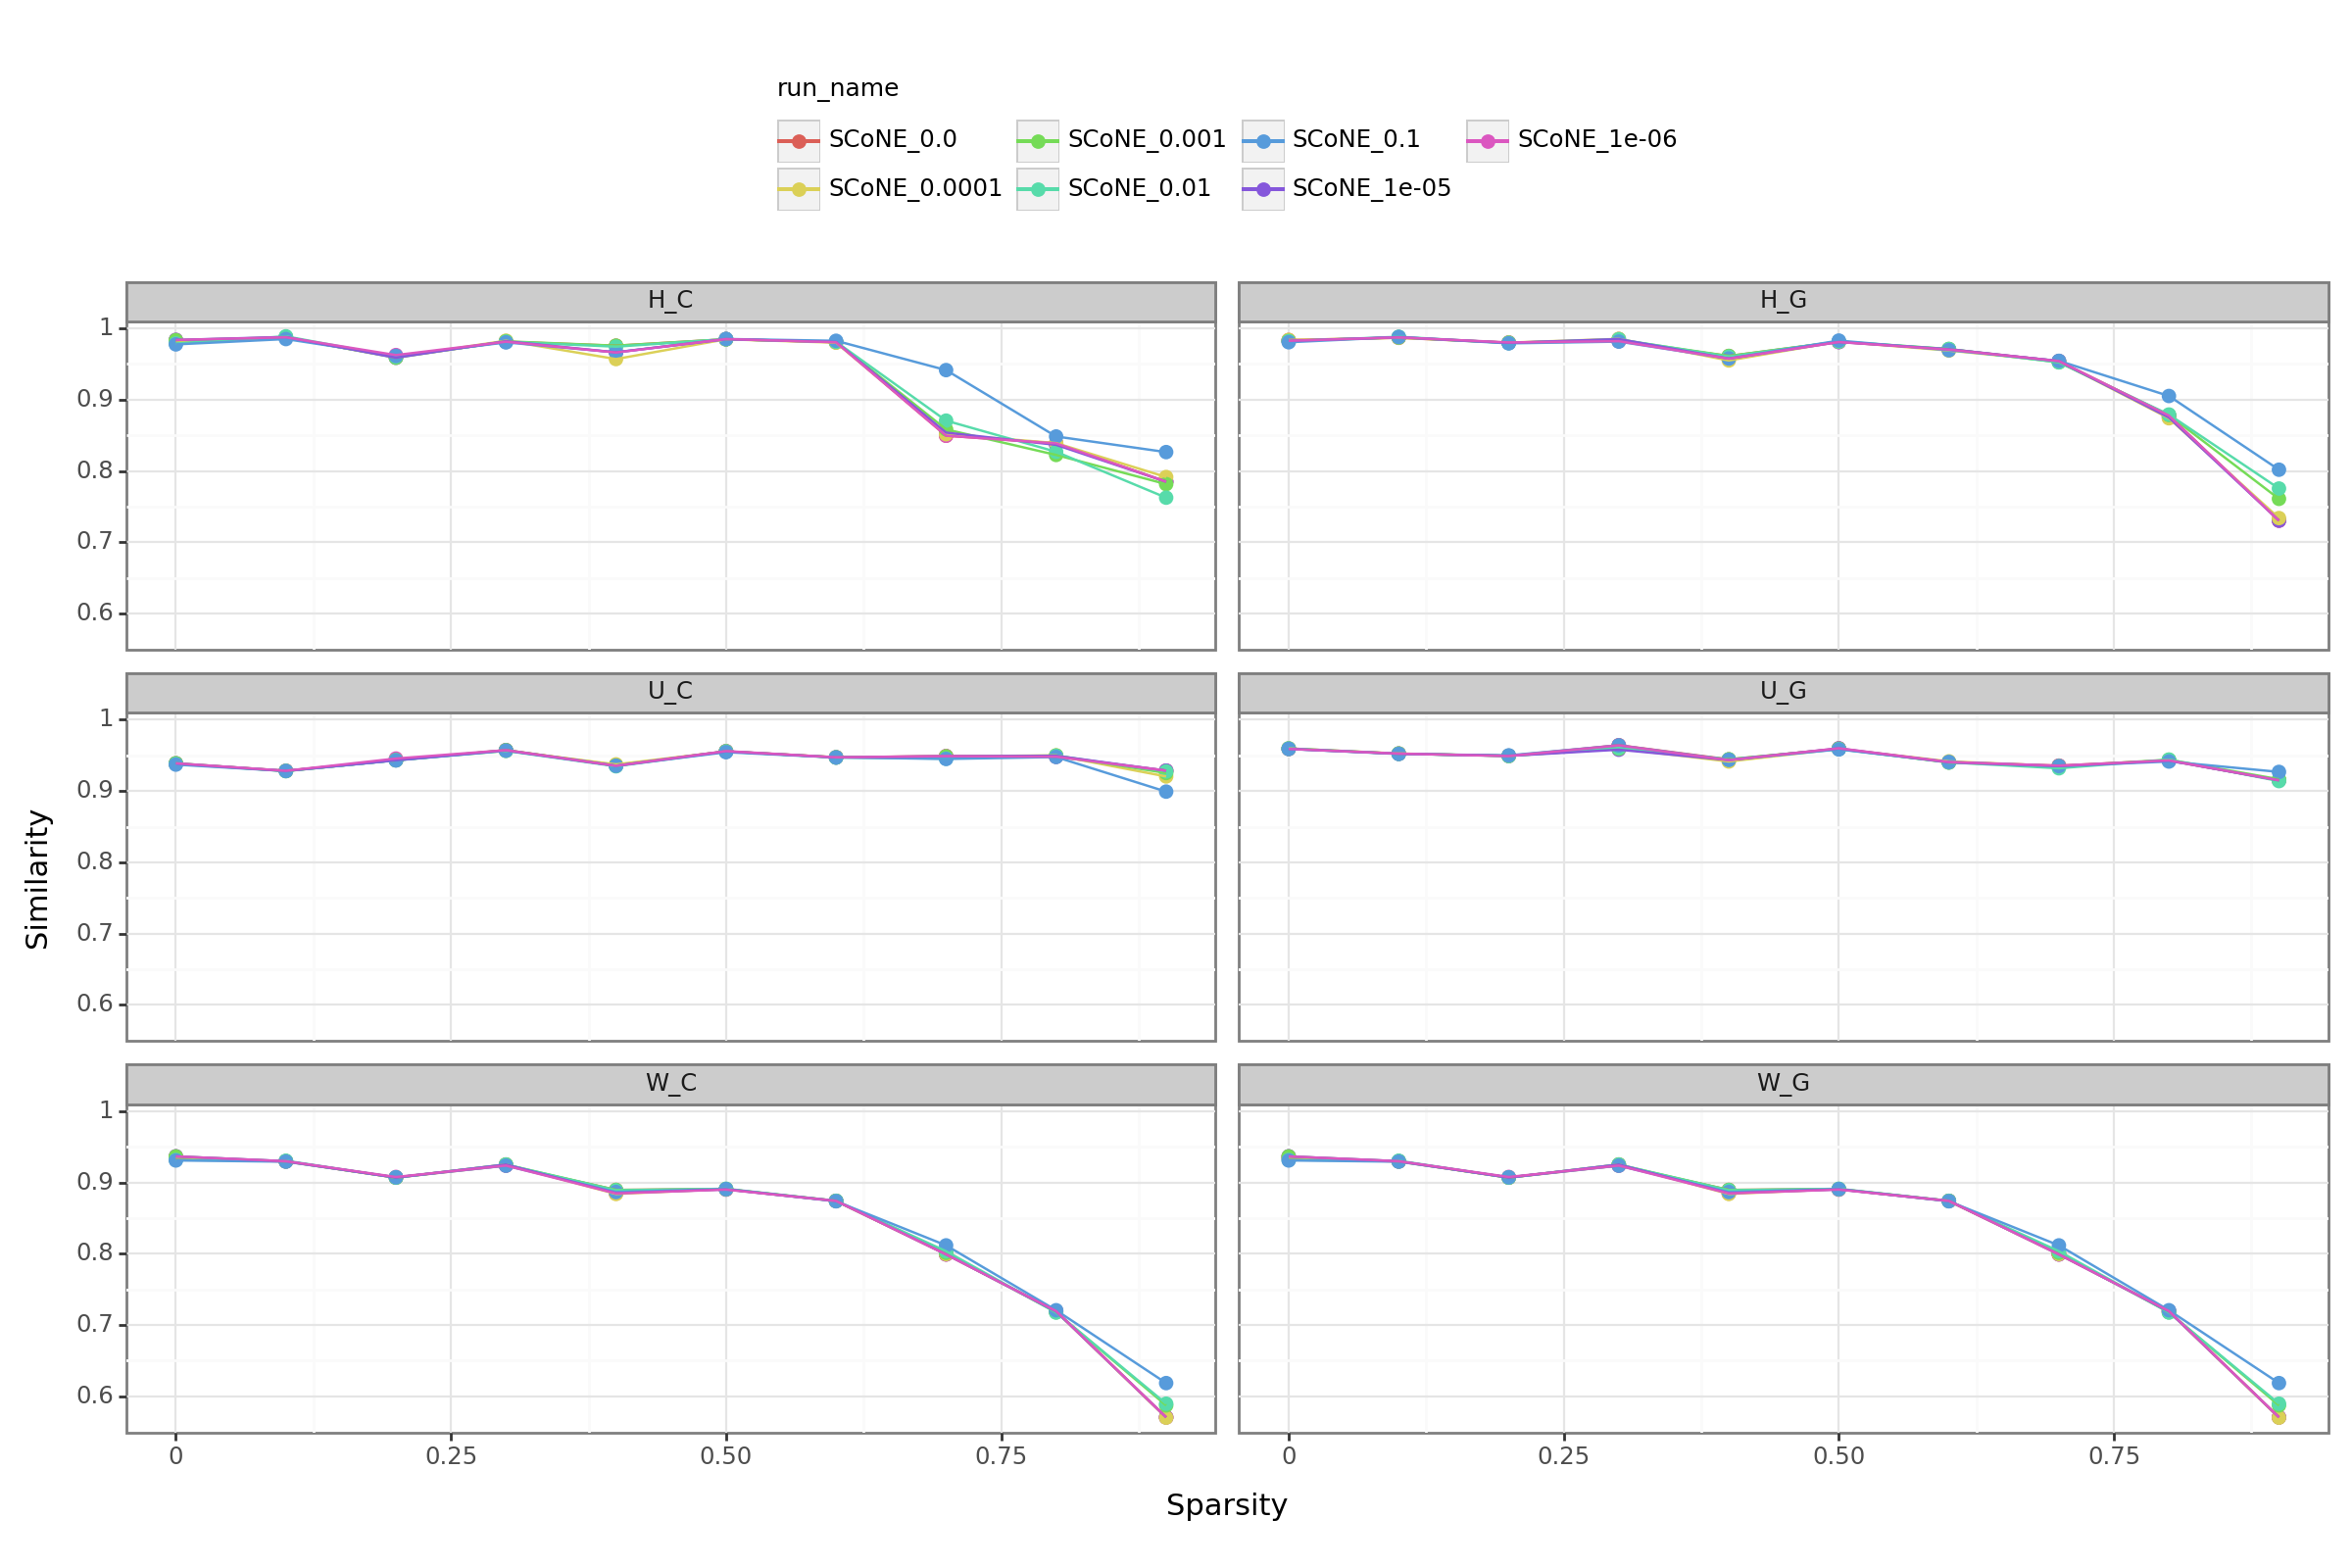

In [98]:
tuning_results = pd.read_csv("/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_tuning_results.csv",index_col=0)
tuning_results = tuning_results[tuning_results['lambda_H_G']<1].copy()
tuning_results['run_name'] = tuning_results.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']),axis=1)
p = (
    ggplot(tuning_results, aes("sparsity", "sim", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + facet_wrap('factor_matrix',nrow=3)
    + labs(y='Similarity',x="Sparsity")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

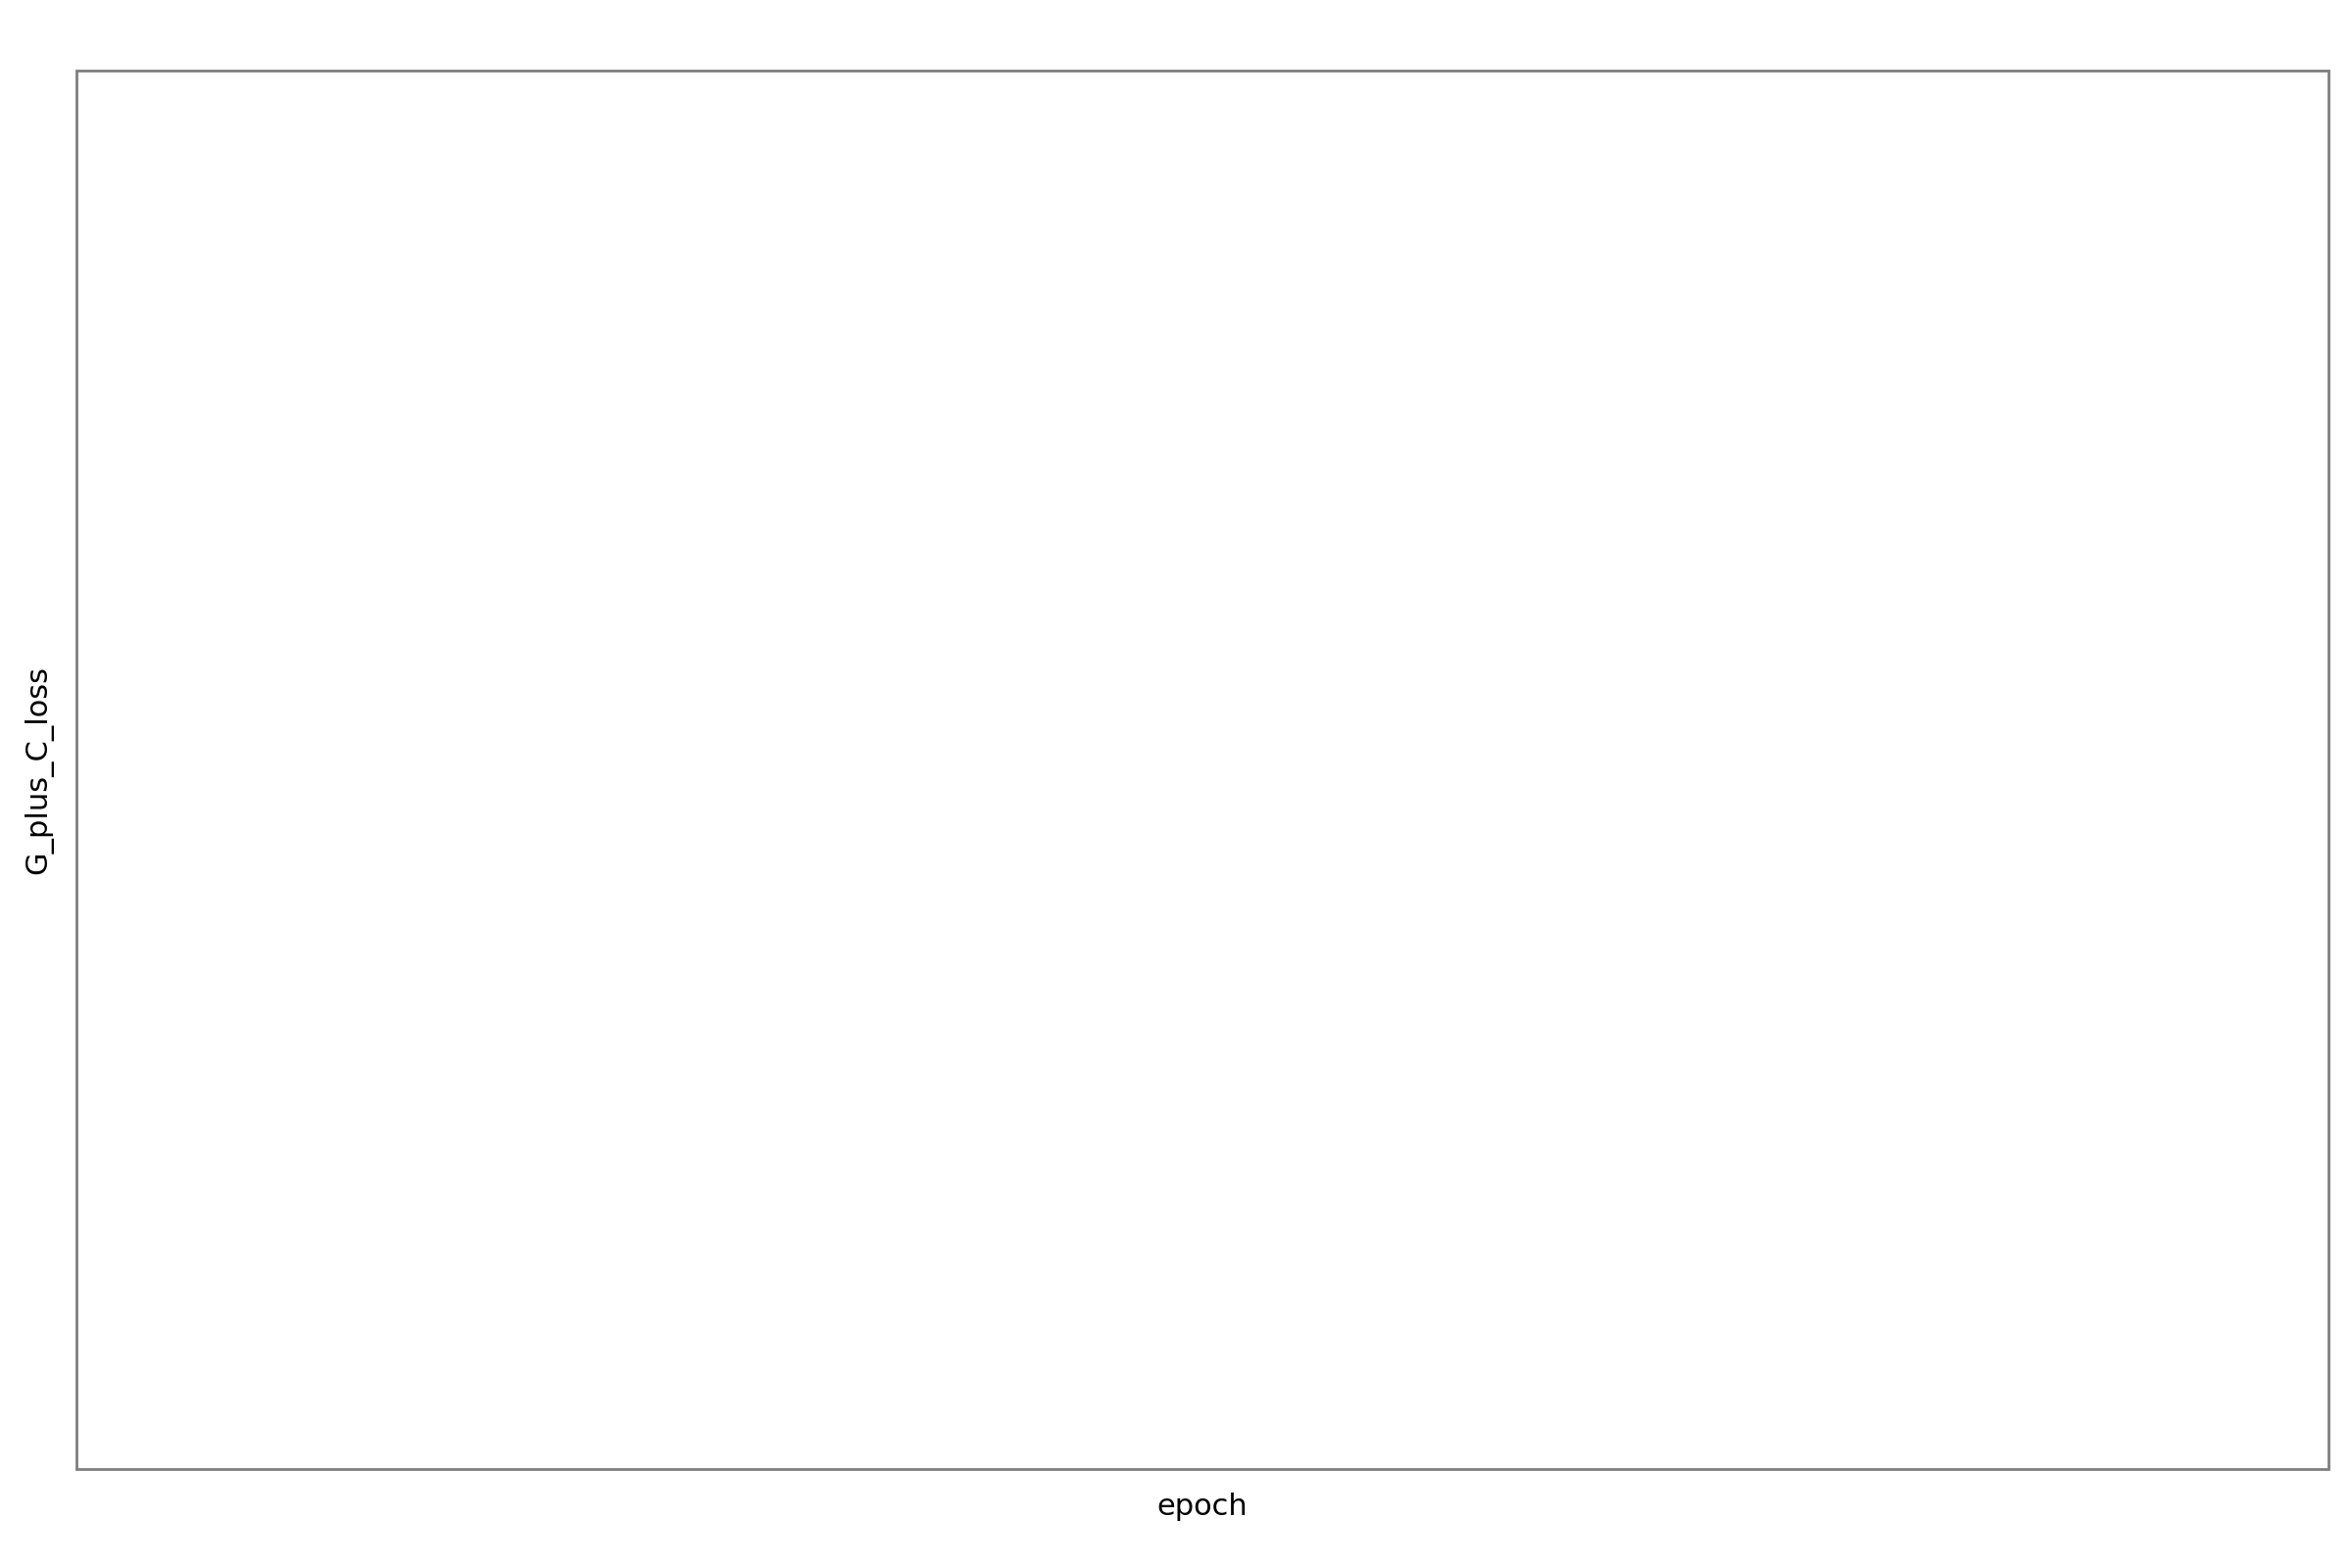

In [82]:
import json
import pandas as pd
import numpy as np
from plotnine import *
all_loss_functions = []
for lambda_val in [1e-6,1e-5,1e-4,1e-3,1e-2,1]:
    for sparsity in np.arange(0,1,0.1):
        with open(f"/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/models/loss_function_lambdaval_{lambda_val}_sparsity_{sparsity}.json","r") as f:
            loss_function = json.load(f)
            loss_function_df = pd.DataFrame(loss_function).reset_index(names='epoch')
            loss_function_df['lambda'] = str(lambda_val)
            loss_function_df['sparsity'] = sparsity
            all_loss_functions.append(loss_function_df)

all_loss_functions = pd.concat(all_loss_functions)
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.7], aes("epoch", "G_plus_C_loss", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

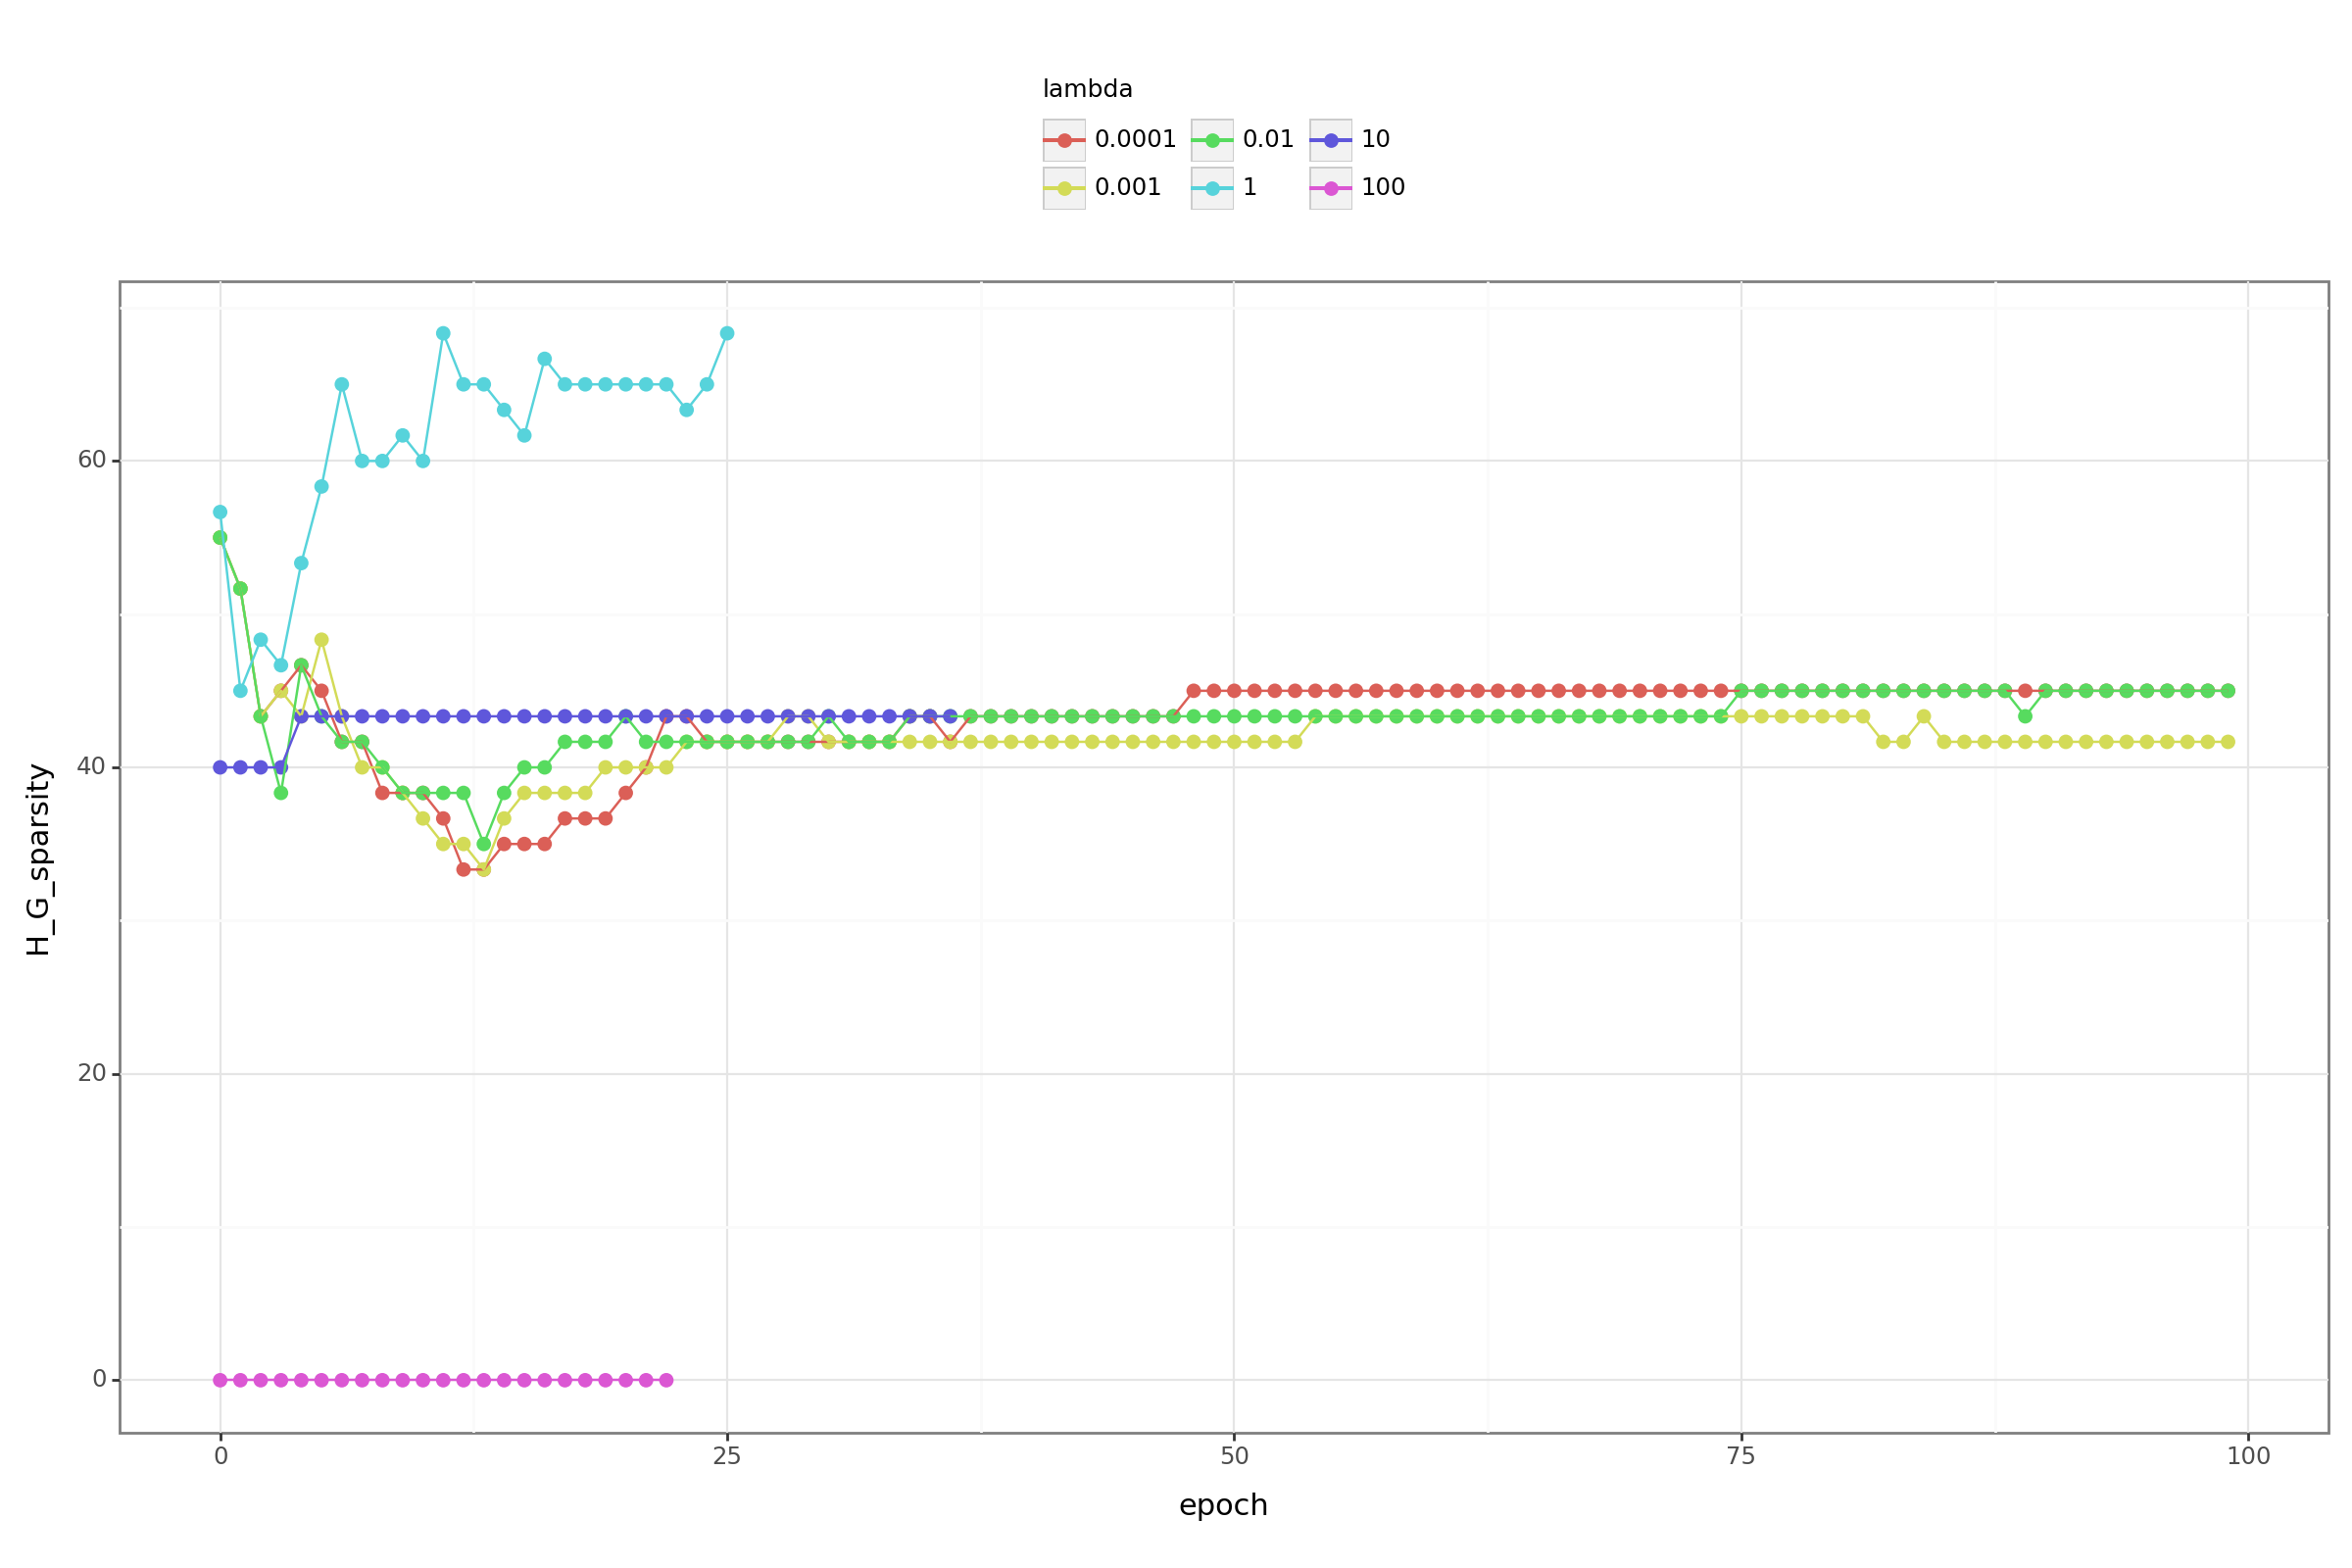

In [71]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "H_G_sparsity", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

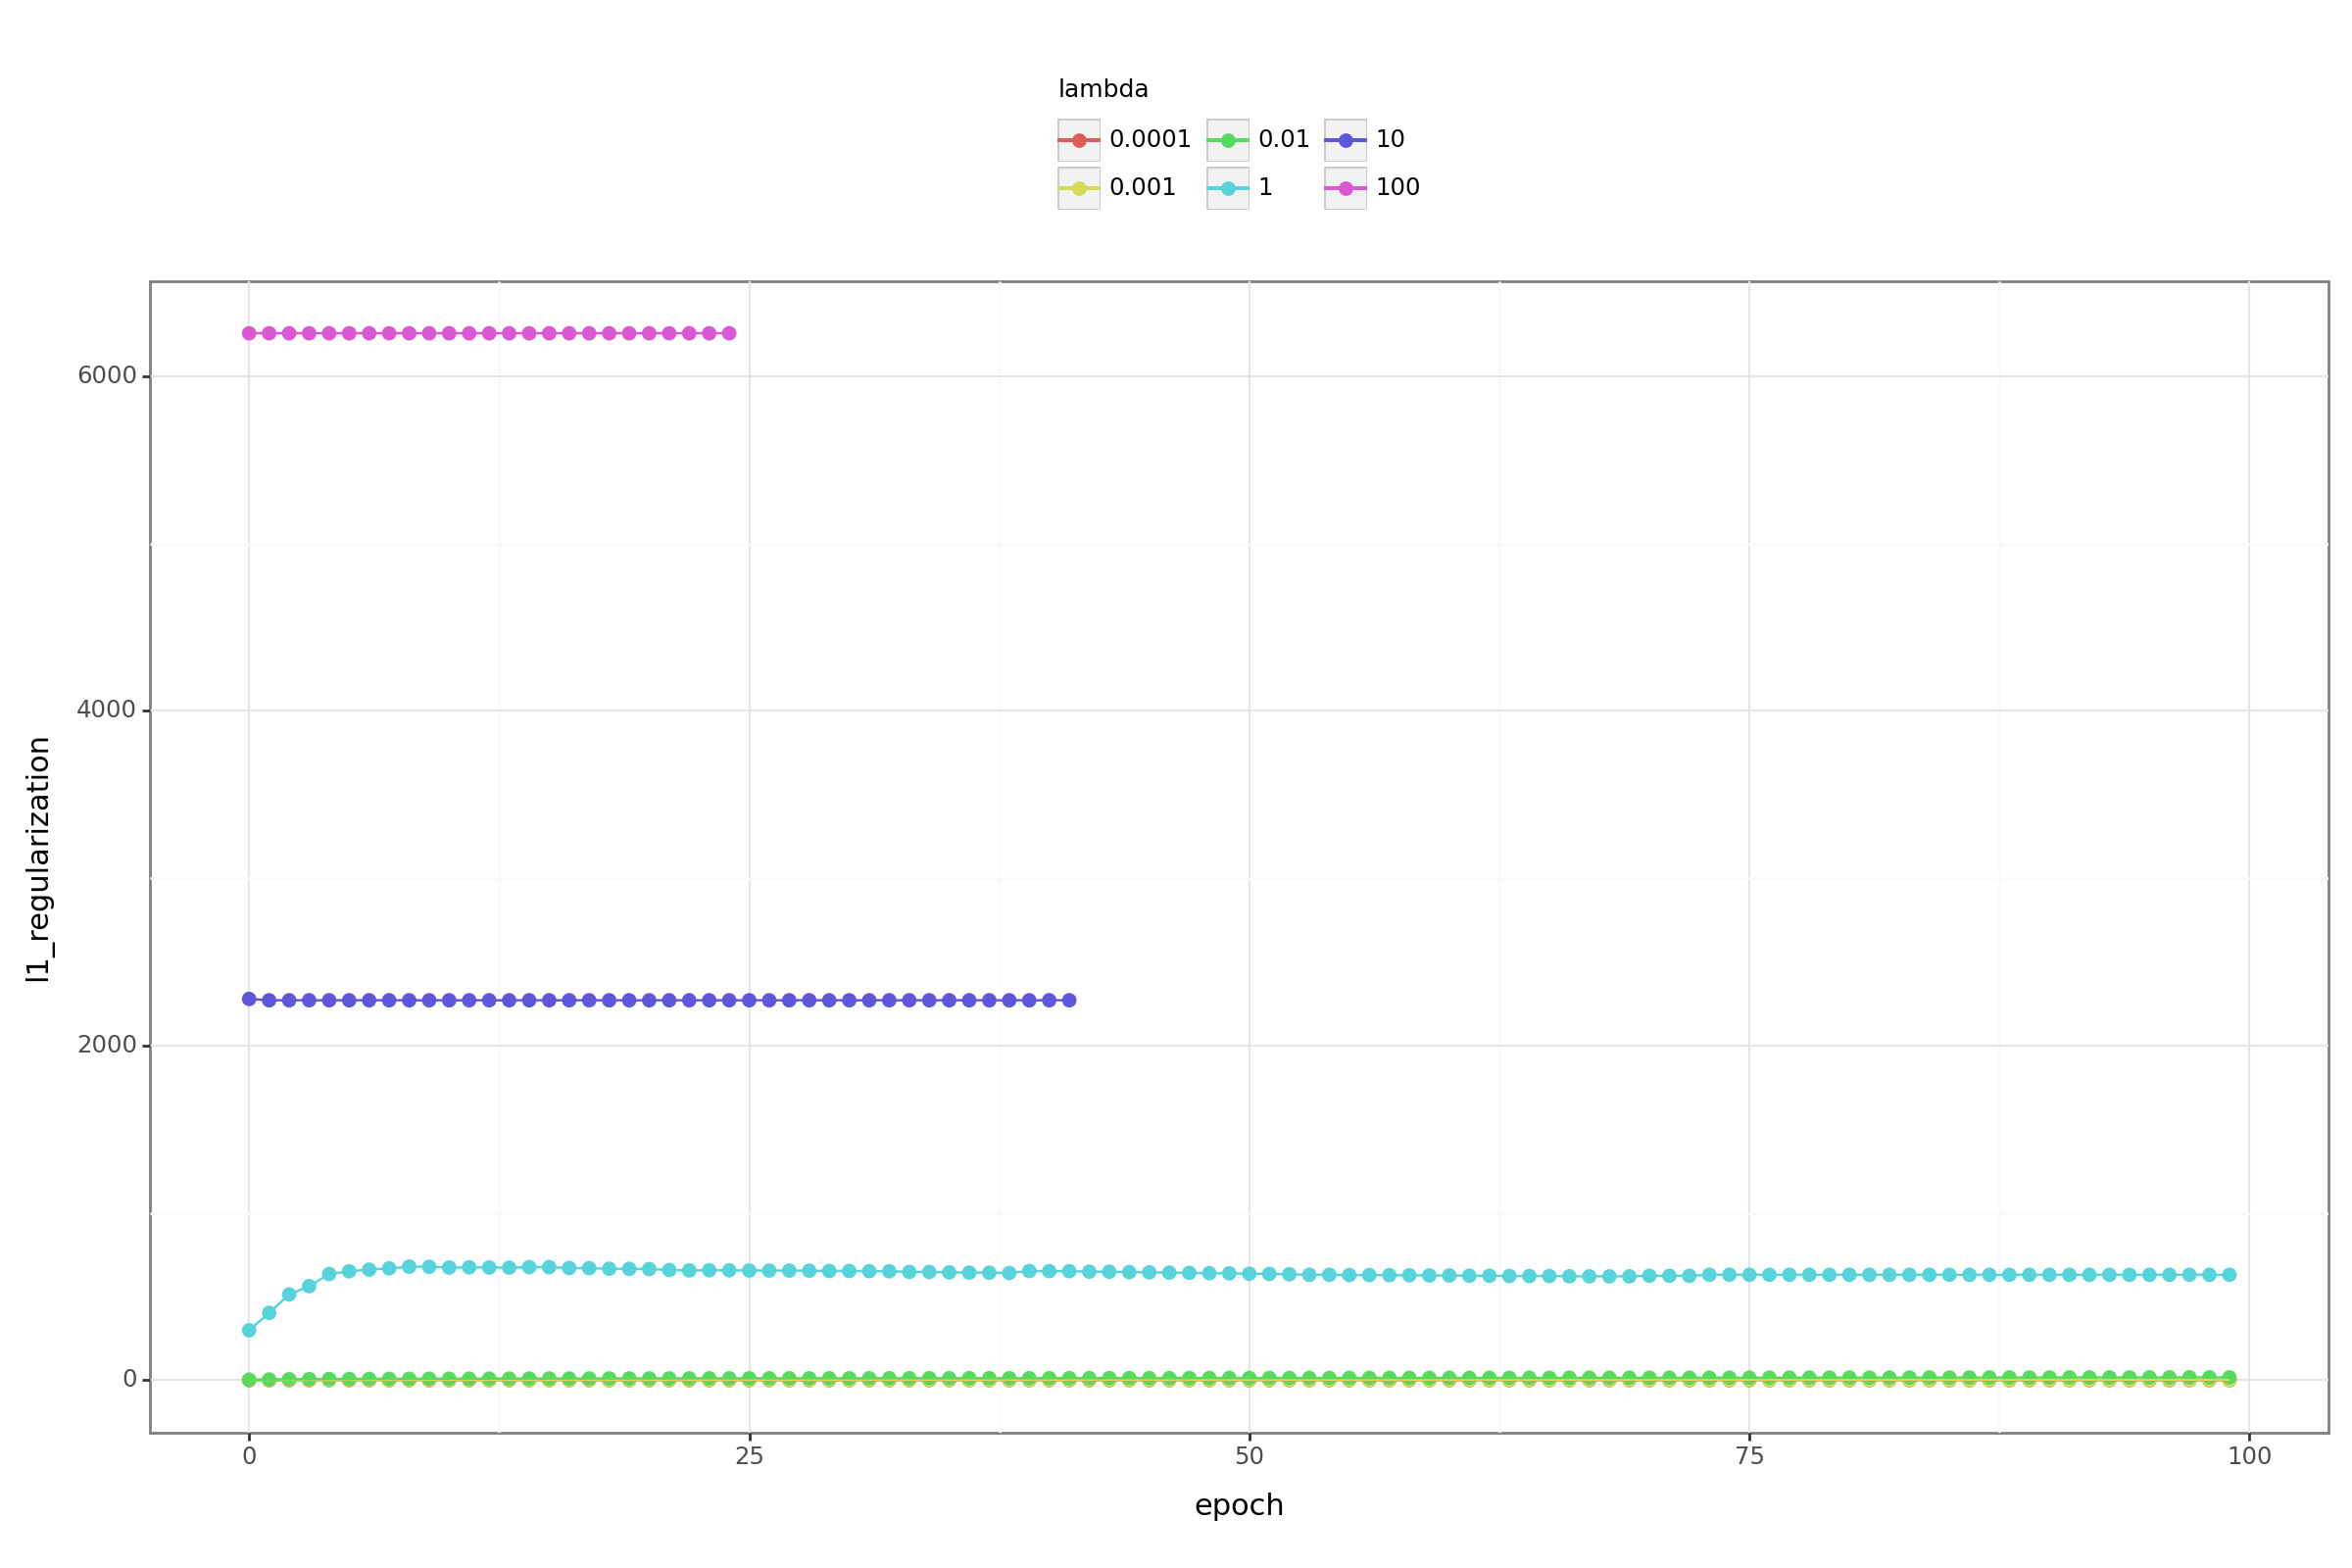

In [33]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "l1_regularization", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

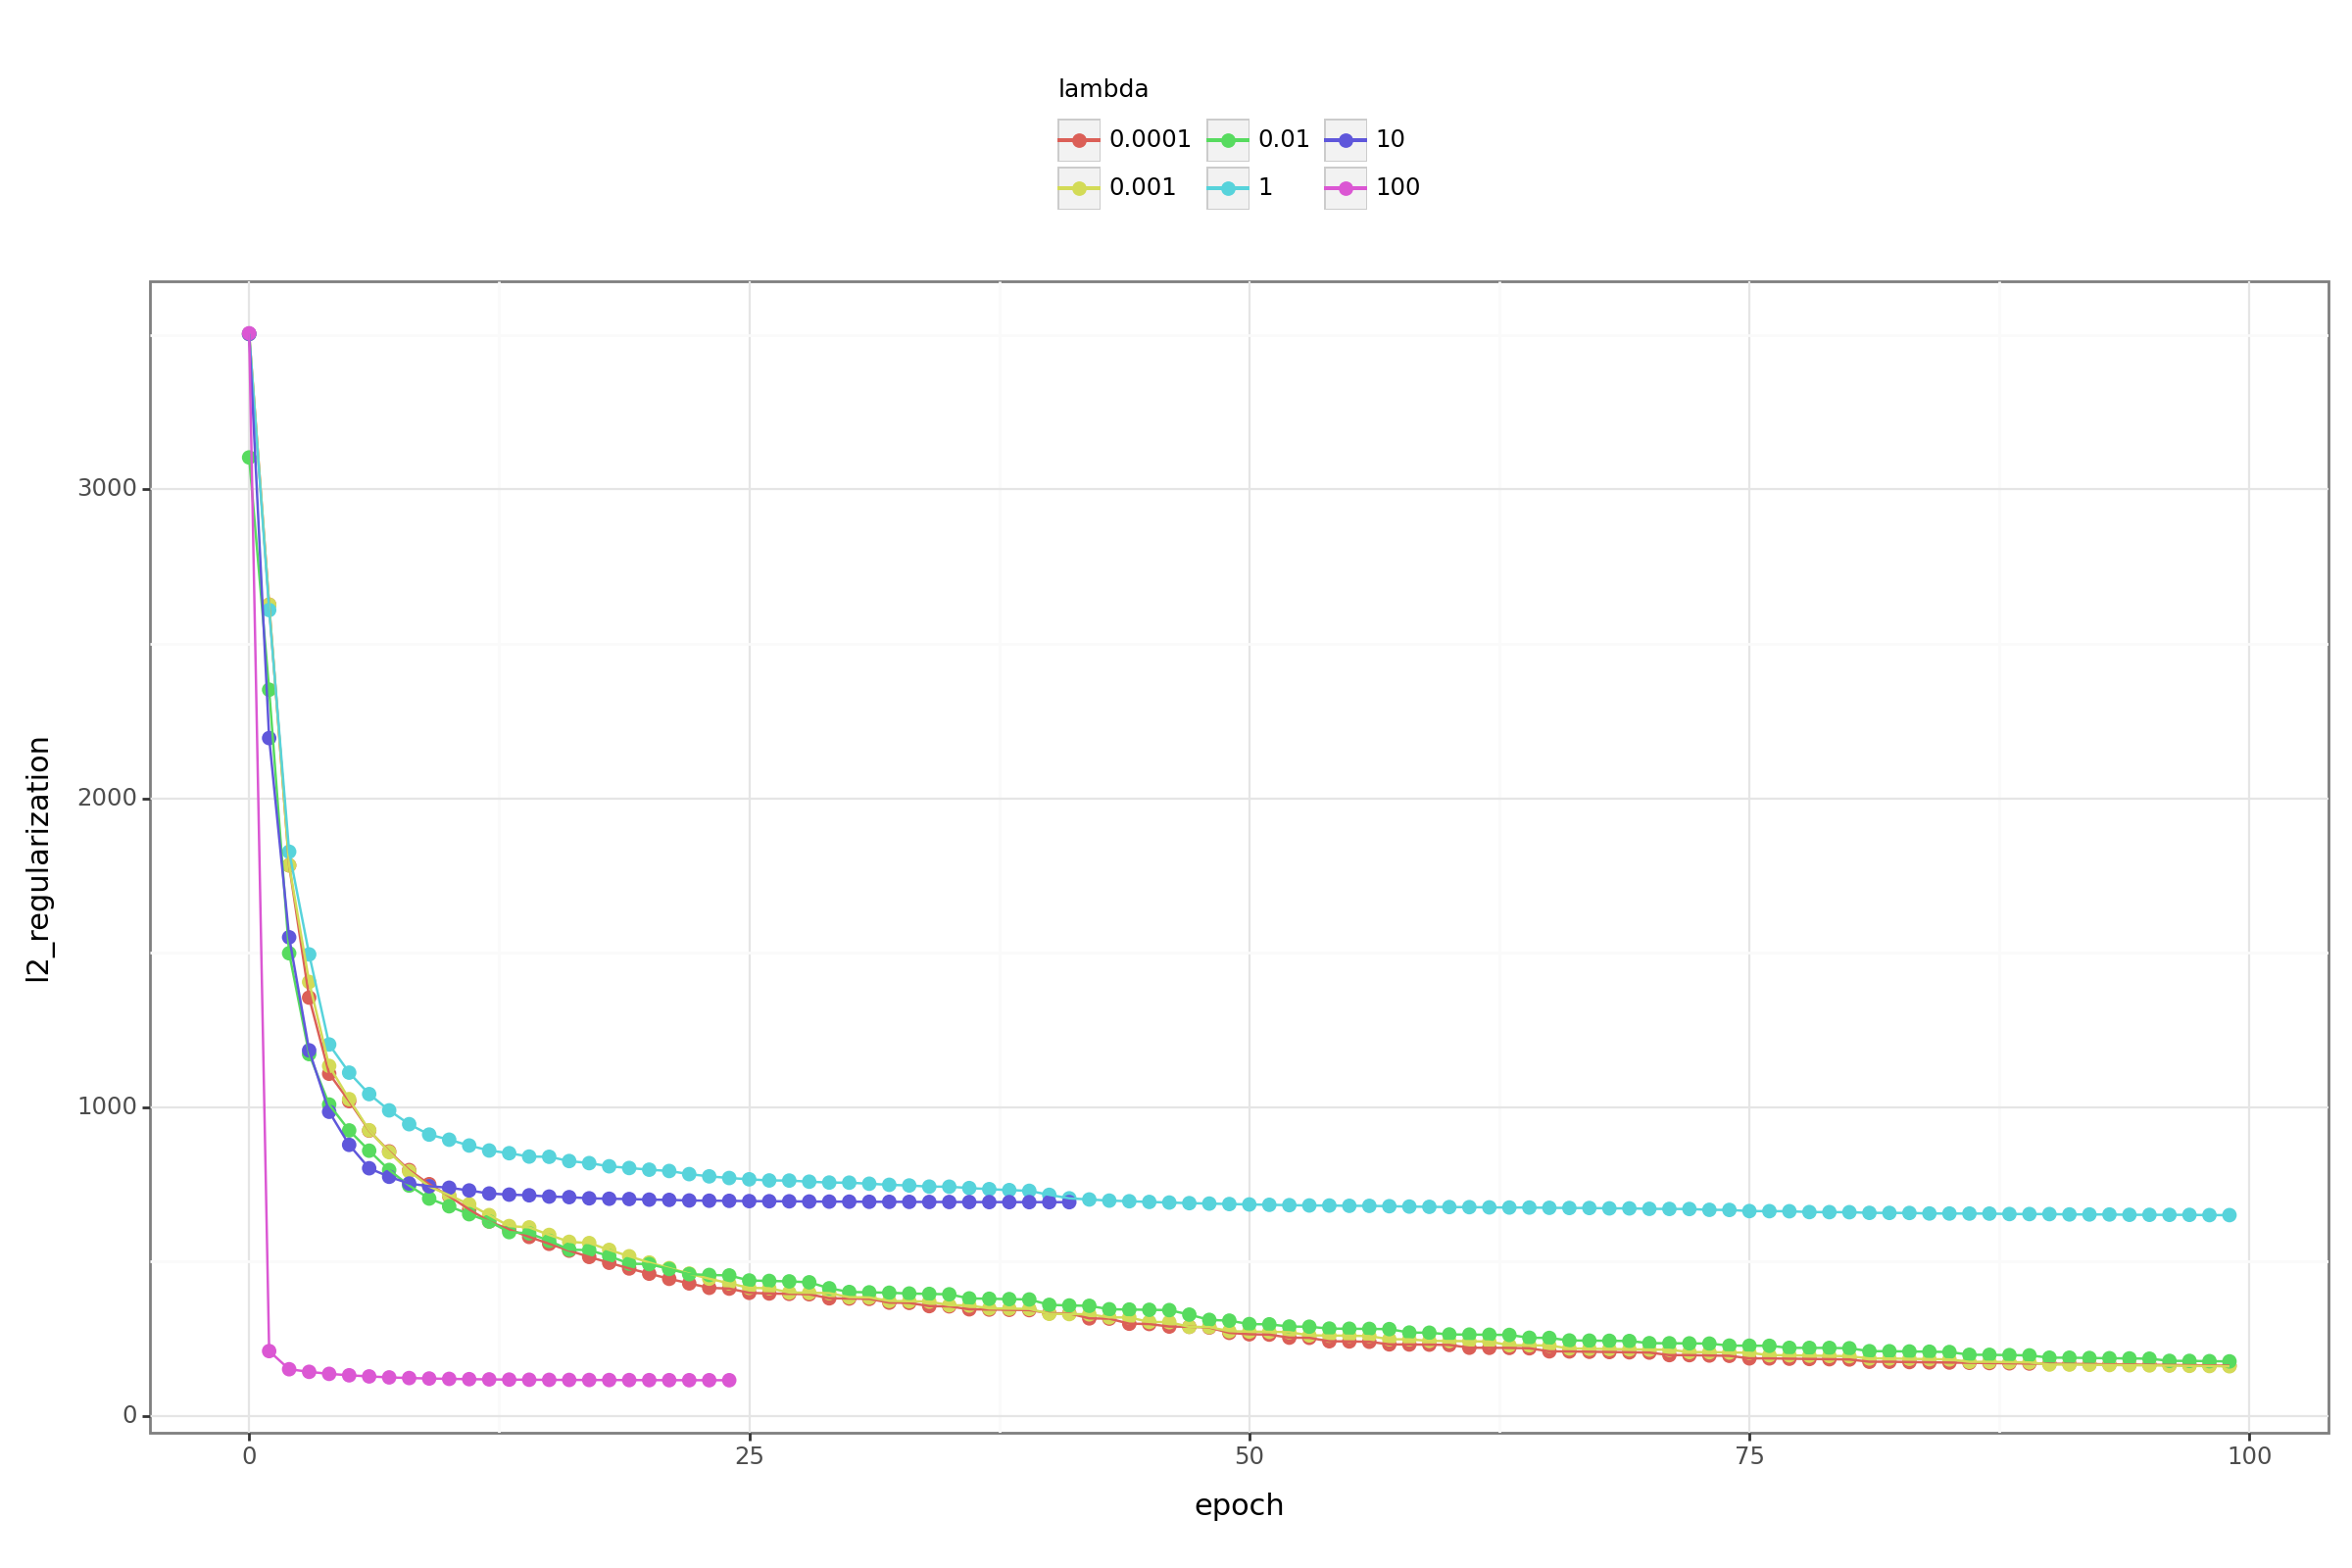

In [34]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "l2_regularization", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)